In [1]:
import os
import sys

sys.stderr = open(os.devnull, "w")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Input, Dense, LSTM, Dropout

warnings.filterwarnings('ignore', category=FutureWarning)

tf.random.set_seed(42)
np.random.seed(42)

In [2]:
sales = pd.read_csv('pedidos.csv', sep=';')

In [3]:
df_count = sales[['account_id', 'sales_channel_id']].value_counts()
df_count = pd.DataFrame(df_count).reset_index()

In [4]:
EPOCHS = 1000
BATCH_SIZE = 32
VALID_SPLIT = 0.1

In [5]:
ALL_SALES_CHANNELS = True
LOOKBACK = 3
CRIT_VALUE = 0.25
END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
START_DATE = END_DATE - timedelta(hours=END_DATE.hour)
TEST_SIZE = int((END_DATE - START_DATE).seconds / 60**2 + 1)

In [6]:
OOT_DATE = START_DATE + timedelta(hours=23)

In [7]:
OOT_PERIODS = int((OOT_DATE - END_DATE).seconds / 60**2 + 1)

In [8]:
oot_dates = pd.DatetimeIndex([END_DATE+timedelta(hours=h) for h in range(1, OOT_PERIODS)], freq='h')
df_oot = pd.DataFrame(index=oot_dates)

Processing account_id: 0661e926-f219-456e-bde5-612fee6f891c, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 555.0647 - val_loss: 968.2271
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 554.7123 - val_loss: 967.7811
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 553.9038 - val_loss: 966.8775
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 552.3527 - val_loss: 965.2588
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 549.6821 - val_loss: 962.7243
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 545.7682 - val_loss: 959.1216
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 541.1695 - val_loss: 954.5338
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 534.8217 - val_loss: 948.9315
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 528.0269 - val_loss: 942.3866
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 520.4885 - val_loss: 934.9749
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 512.5858 - val_loss: 926.7565
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 505.0070 - val_loss: 918.1584
Ep

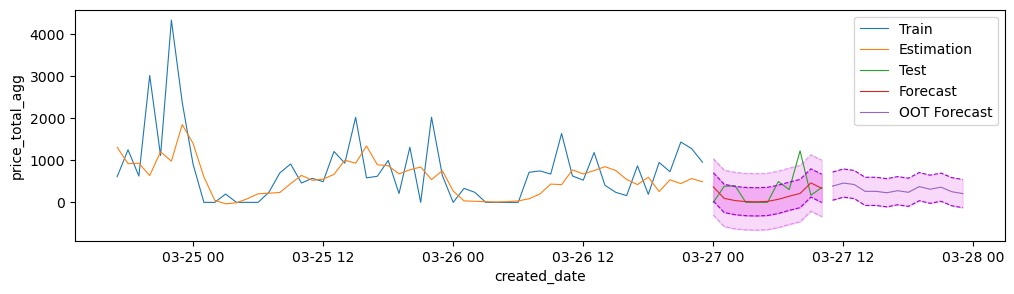

Processing column: n_orders
Epoch 1/1000
60/60 - 3s - 45ms/step - loss: 2.6230 - val_loss: 4.9581
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 2.3720 - val_loss: 4.7124
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 2.2121 - val_loss: 4.4239
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 2.1467 - val_loss: 4.1353
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 2.0993 - val_loss: 4.0075
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 2.0557 - val_loss: 3.9155
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 2.0153 - val_loss: 3.7974
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1.9966 - val_loss: 3.6828
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 1.9612 - val_loss: 3.5933
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 1.9262 - val_loss: 3.4661
Epoch 11/1000
60/60 - 0s - 6ms/step - loss: 1.9054 - val_loss: 3.3741
Epoch 12/1000
60/60 - 0s - 4ms/step - loss: 1.8535 - val_loss: 3.2713
Epoch 13/1000
60/60 - 0s - 4ms/step - loss: 1.8473 - val_loss: 3.1841
Epoch 14/1000
60/60 - 0s - 5ms/step - loss: 1.8412 - val_loss: 3.1085


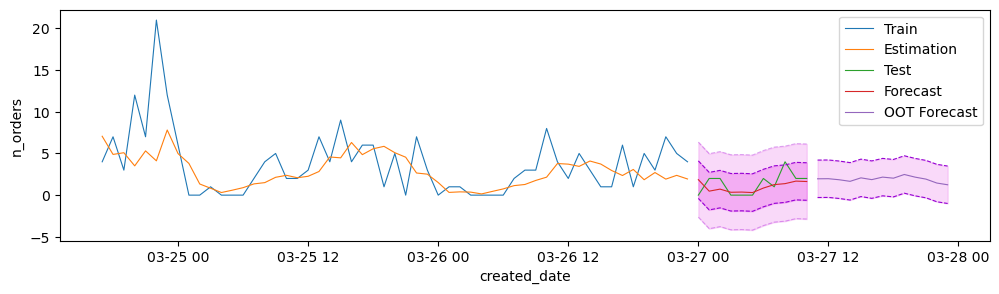

Processing account_id: 457bce7b-9300-4c10-9a97-070b3c0d081d, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 22ms/step - loss: 1214.6615 - val_loss: 1753.0172
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 1214.6395 - val_loss: 1752.9601
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 1214.6033 - val_loss: 1752.8503
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 1214.5355 - val_loss: 1752.6304
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1214.4319 - val_loss: 1752.2236
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 1214.2422 - val_loss: 1751.5918
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1213.9463 - val_loss: 1750.6420
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1213.5503 - val_loss: 1749.3506
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 1212.9325 - val_loss: 1747.7174
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 1212.2372 - val_loss: 1745.7172
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 1211.4850 - val_loss: 1743.4418
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 1210.3987 

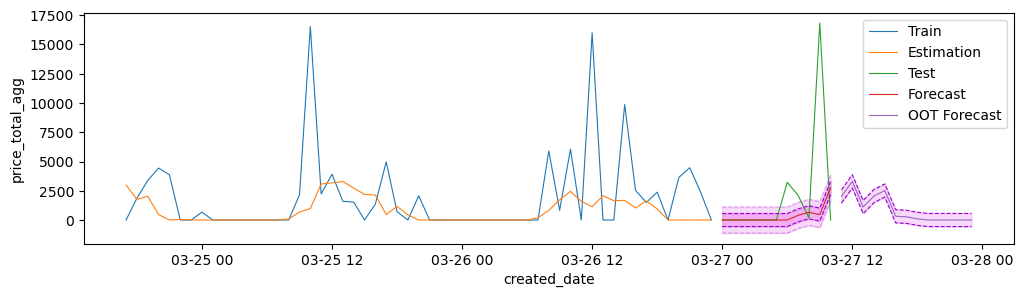

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 0.6049 - val_loss: 0.7538
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.5639 - val_loss: 0.6920
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.5554 - val_loss: 0.6866
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.5544 - val_loss: 0.6867
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.5487 - val_loss: 0.6847
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.5448 - val_loss: 0.6839
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 0.5440 - val_loss: 0.6826
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 0.5394 - val_loss: 0.6838
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 0.5354 - val_loss: 0.6845
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 0.5379 - val_loss: 0.6831
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Epoch 1/1000
61/61 - 1s - 11ms/step - loss: 0.6000 - val_loss: 0.7620
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.5662 - val_loss: 0.6961
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.5534 - val_loss: 0.

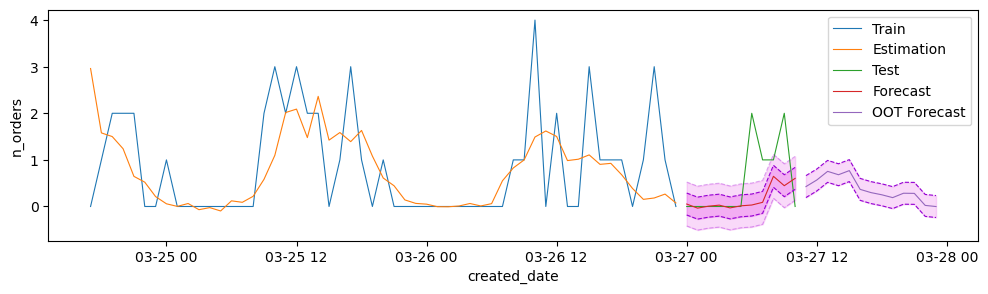

Processing account_id: e2de40dd-743b-4105-9077-3f343fea980d, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 2971.3088 - val_loss: 3025.4155
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 2970.3396 - val_loss: 3023.7505
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 2967.2708 - val_loss: 3019.1338
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 2960.5706 - val_loss: 3010.2395
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 2949.1589 - val_loss: 2996.0657
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 2932.1338 - val_loss: 2976.3369
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 2909.2148 - val_loss: 2951.2891
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 2882.6421 - val_loss: 2921.6421
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 2850.0669 - val_loss: 2887.3677
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 2813.3752 - val_loss: 2848.9287
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 2773.8257 - val_loss: 2806.8579
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 2729.8269 

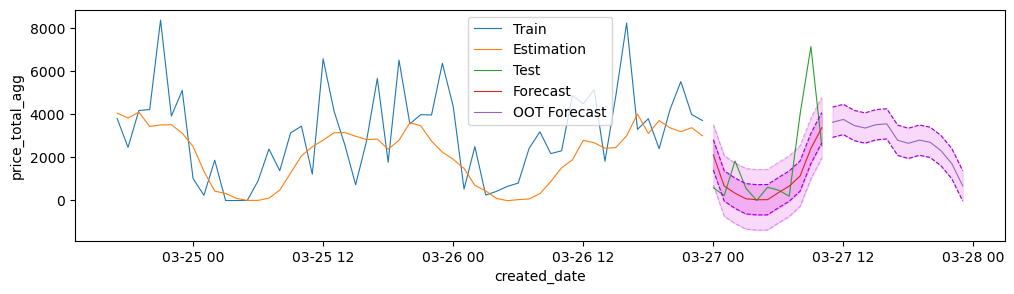

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 22ms/step - loss: 9.7259 - val_loss: 7.6692
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 8.5495 - val_loss: 5.8928
Epoch 3/1000
60/60 - 0s - 6ms/step - loss: 6.1190 - val_loss: 3.8473
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 4.4860 - val_loss: 3.4856
Epoch 5/1000
60/60 - 0s - 5ms/step - loss: 4.2221 - val_loss: 3.4015
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 4.1427 - val_loss: 3.3550
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 4.1362 - val_loss: 3.3433
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 4.0284 - val_loss: 3.3066
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 3.9278 - val_loss: 3.2944
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 3.9861 - val_loss: 3.2699
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 3.8816 - val_loss: 3.2592
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 3.9779 - val_loss: 3.2593
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 3.9803 - val_loss: 3.2664
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 3.9086 - val_loss: 3.2533


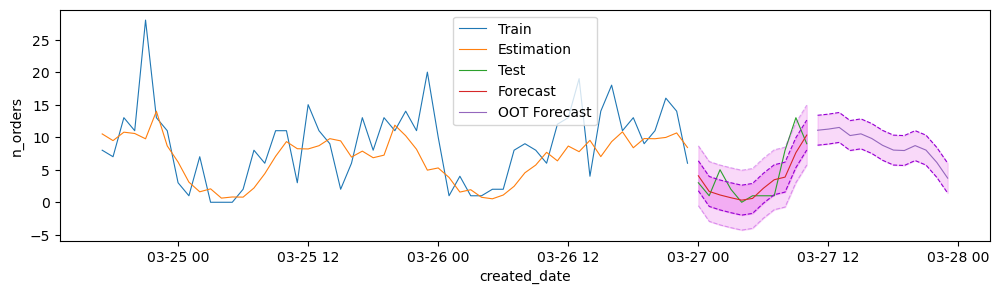

Processing account_id: bfcbb283-4e53-41fd-9b31-aa818f7f23ce, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 3s - 42ms/step - loss: 369.3190 - val_loss: 626.2408
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 368.5271 - val_loss: 624.8509
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 366.0967 - val_loss: 621.0591
Epoch 4/1000
60/60 - 0s - 5ms/step - loss: 360.8949 - val_loss: 614.2379
Epoch 5/1000
60/60 - 0s - 6ms/step - loss: 353.3395 - val_loss: 605.0742
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 344.0790 - val_loss: 594.4870
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 334.3863 - val_loss: 584.3904
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 326.2427 - val_loss: 575.8809
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 319.3226 - val_loss: 569.3132
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 313.4944 - val_loss: 563.1378
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 309.8848 - val_loss: 557.8893
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 307.0227 - val_loss: 553.4348
Ep

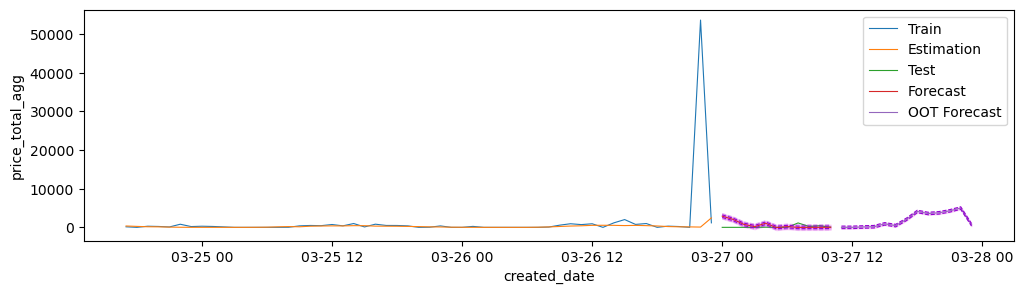

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 21ms/step - loss: 1.4240 - val_loss: 1.2886
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 1.0811 - val_loss: 1.1782
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 1.0406 - val_loss: 1.1641
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 1.0345 - val_loss: 1.1583
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 1.0175 - val_loss: 1.1537
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 1.0152 - val_loss: 1.1515
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 1.0112 - val_loss: 1.1507
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 0.9925 - val_loss: 1.1556
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 1.0074 - val_loss: 1.1493
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 0.9985 - val_loss: 1.1451
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 0.9936 - val_loss: 1.1469
Epoch 12/1000
60/60 - 0s - 5ms/step - loss: 0.9819 - val_loss: 1.1455
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 0.9861 - val_loss: 1.1466
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34m

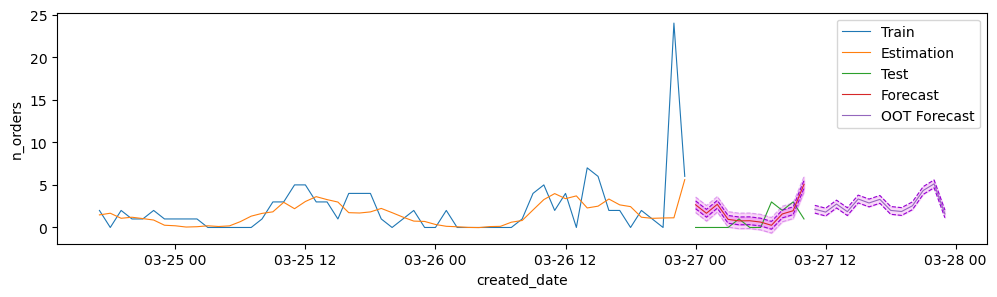

Processing account_id: 423a069b-27b8-44ed-9ef3-ca3cf9470970, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 77.9753 - val_loss: 9483.3066
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 77.9747 - val_loss: 9483.2979
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 77.9746 - val_loss: 9483.2832
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 77.9746 - val_loss: 9483.2656
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 77.9746 - val_loss: 9483.2480
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 77.9745 - val_loss: 9483.2285
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 77.9745 - val_loss: 9483.1943
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 77.9744 - val_loss: 9483.1416
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 77.9744 - val_loss: 9483.0869
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 77.9744 - val_loss: 9483.0254
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 77.9743 - val_loss: 9482.9463
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 77.9742 - val_loss: 9482.8564
Ep

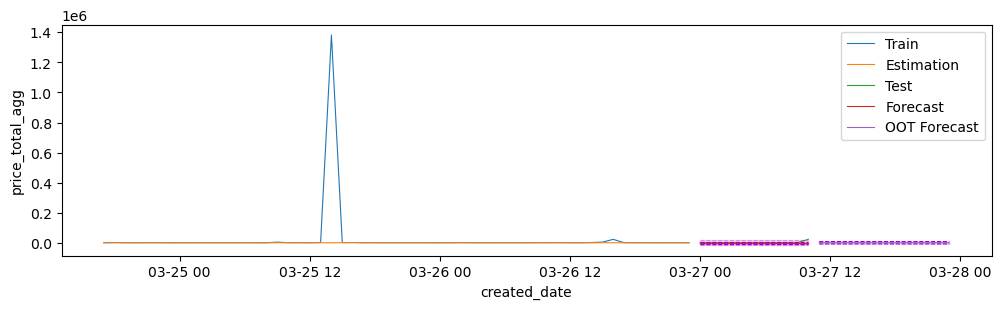

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 25ms/step - loss: 0.3624 - val_loss: 221.1300
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 0.3618 - val_loss: 221.1296
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.3619 - val_loss: 221.1278
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.3618 - val_loss: 221.1268
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 0.3618 - val_loss: 221.1215
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 0.3619 - val_loss: 221.1206
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 0.3619 - val_loss: 221.1190
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 0.3618 - val_loss: 221.1195
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 0.3618 - val_loss: 221.1171
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.1167
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.1159
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 0.3618 - val_loss: 221.1142
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 0.3618 - val_loss: 221.1086
Epoch 14/1000
60/60 - 0s - 2ms/step - loss: 

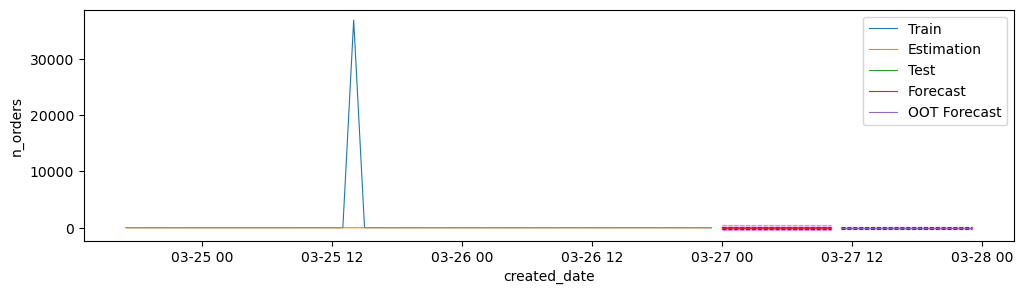

Processing account_id: 3dc15e4b-b60d-4c49-aae8-97cf9664af51, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 24ms/step - loss: 36.3357 - val_loss: 49.5046
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 36.3269 - val_loss: 49.4990
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 36.3186 - val_loss: 49.4918
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 36.3108 - val_loss: 49.4797
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 36.3015 - val_loss: 49.4666
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 36.2845 - val_loss: 49.4538
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 36.2706 - val_loss: 49.4277
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 36.2580 - val_loss: 49.4098
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 36.2353 - val_loss: 49.3746
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 36.2168 - val_loss: 49.3418
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 36.2001 - val_loss: 49.3050
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 36.1843 - val_loss: 49.2840
Epoch 13/1000
60/60 - 0s -

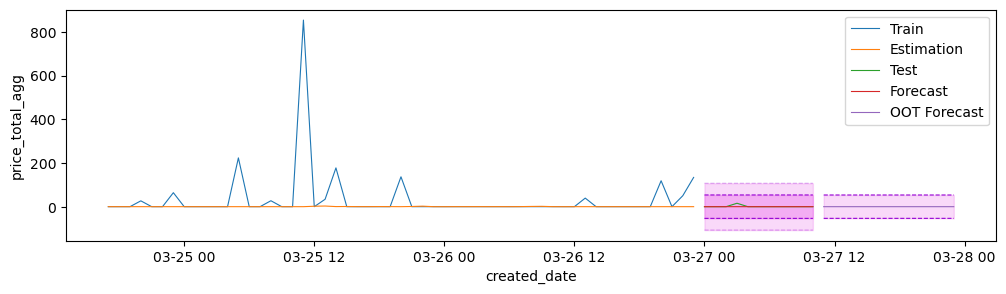

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 18ms/step - loss: 0.4377 - val_loss: 0.6453
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.4289 - val_loss: 0.6251
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.4222 - val_loss: 0.6254
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.4196 - val_loss: 0.6278
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 0.4191 - val_loss: 0.6299
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Epoch 1/1000
61/61 - 1s - 24ms/step - loss: 0.4338 - val_loss: 0.6351
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 0.4300 - val_loss: 0.6272
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 0.4222 - val_loss: 0.6249
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 0.4180 - val_loss: 0.6167
Epoch 5/1000
61/61 - 0s - 3ms/step - loss: 0.4160 - val_loss: 0.6147
Epoch 6/1000
61/61 - 0s - 3ms/step - loss: 0.4163 - val_loss: 0.6213
Epoch 7/1000
61/61 - 0s - 3ms/step - loss: 0.4151 - val_loss: 0.6217
Epoch 8/1000
61/61 - 0s - 3ms/step - loss: 0.4162 - val_loss: 0.6

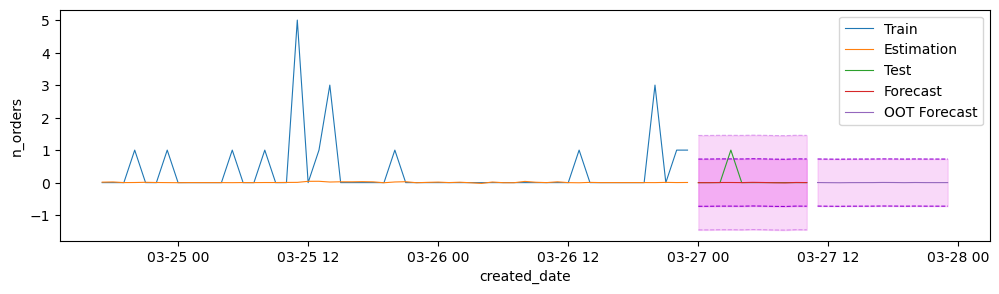

Processing account_id: 7412074f-0f3a-4724-b035-7fb4db3174c8, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 15ms/step - loss: 970.0660 - val_loss: 703.3215
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 969.5132 - val_loss: 703.2459
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 968.2749 - val_loss: 703.1712
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 965.8230 - val_loss: 703.1512
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 961.7896 - val_loss: 703.2913
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 955.6210 - val_loss: 703.6342
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 947.0557 - val_loss: 704.2202
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Epoch 1/1000
61/61 - 1s - 23ms/step - loss: 970.2436 - val_loss: 653.1124
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 969.7586 - val_loss: 653.0942
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 968.6988 - val_loss: 653.1363
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 966.5022 - val_loss: 653.3051


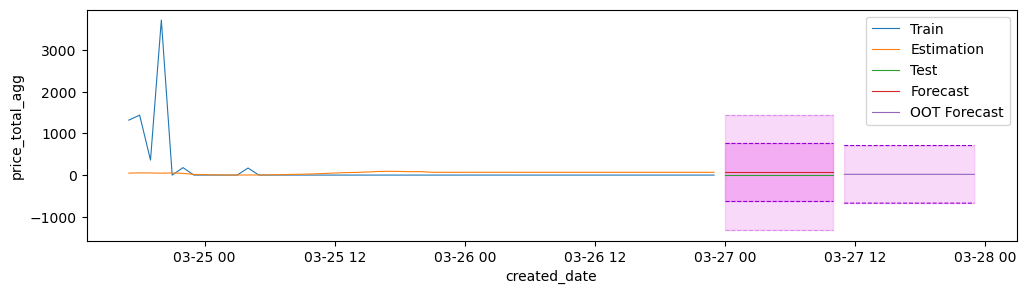

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 26ms/step - loss: 2.2255 - val_loss: 1.6419
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 1.8144 - val_loss: 1.6723
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 1.5675 - val_loss: 1.7977
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.5209 - val_loss: 1.7652
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epoch 1/1000
61/61 - 1s - 13ms/step - loss: 2.2342 - val_loss: 1.5745
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 1.8301 - val_loss: 1.6975
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 1.5798 - val_loss: 1.8044
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 1.5277 - val_loss: 1.7991
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

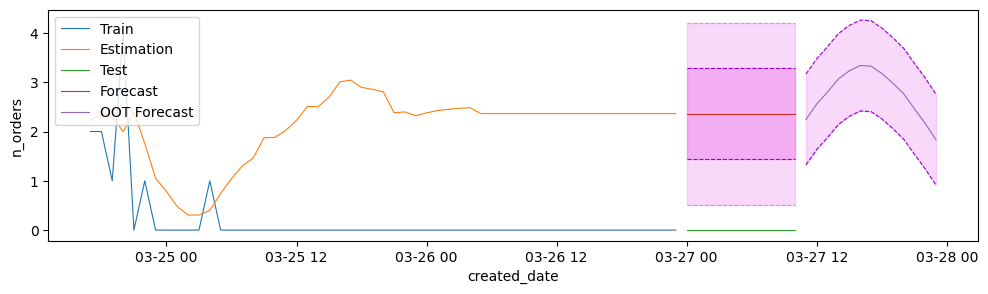

Processing account_id: b009c05b-326e-4ebe-988c-8d2229ec3a4c, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 822.7520 - val_loss: 617.5352
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 822.0392 - val_loss: 616.4962
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 819.5951 - val_loss: 613.5020
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 814.0776 - val_loss: 607.7637
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 805.1752 - val_loss: 599.3925
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 793.6138 - val_loss: 588.6795
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 780.0269 - val_loss: 576.4508
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 763.7621 - val_loss: 562.7393
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 747.6357 - val_loss: 548.9371
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 730.1130 - val_loss: 535.8237
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 713.8512 - val_loss: 522.6672
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 697.8798 - val_loss: 510.4725
Ep

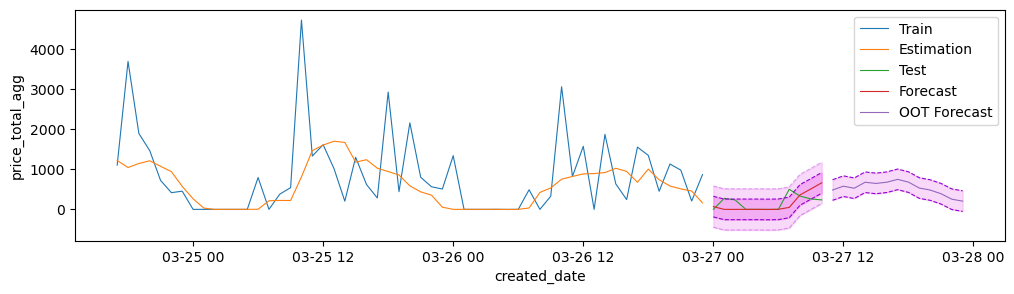

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 35ms/step - loss: 2.0014 - val_loss: 1.3287
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 1.5226 - val_loss: 1.0681
Epoch 3/1000
60/60 - 0s - 5ms/step - loss: 1.3829 - val_loss: 1.0454
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.3571 - val_loss: 1.0369
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 1.3451 - val_loss: 1.0355
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 1.3369 - val_loss: 1.0344
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.3138 - val_loss: 1.0345
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 1.3125 - val_loss: 1.0392
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 1.2973 - val_loss: 1.0361
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Epoch 1/1000
61/61 - 2s - 31ms/step - loss: 1.9416 - val_loss: 1.2567
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 1.4660 - val_loss: 1.0499
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 1.3722 - val_loss: 1.0366
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 1.3390 - val_loss: 1.0

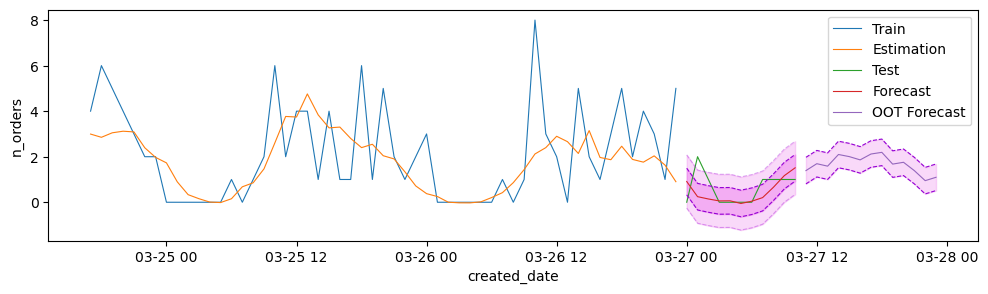

Processing account_id: 6cd2fa8a-5bac-4cc0-b4df-bd2c7d29e71b, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 25ms/step - loss: 144.2581 - val_loss: 88.7798
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 144.1964 - val_loss: 88.7781
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 144.0747 - val_loss: 88.7647
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 143.8458 - val_loss: 88.7221
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 143.2989 - val_loss: 88.6176
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 142.3905 - val_loss: 88.4341
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 141.1653 - val_loss: 88.1778
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 139.4808 - val_loss: 87.8547
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 137.8551 - val_loss: 87.5154
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 136.2446 - val_loss: 87.1921
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 135.0414 - val_loss: 86.9040
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 134.0276 - val_loss: 86.8598
Epoch 13/1000


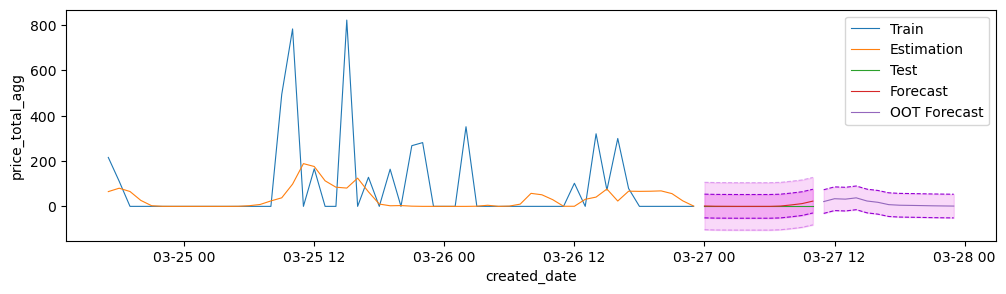

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 22ms/step - loss: 0.6849 - val_loss: 0.4603
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 0.6263 - val_loss: 0.4621
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.6157 - val_loss: 0.4607
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.6064 - val_loss: 0.4617
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Epoch 1/1000
61/61 - 2s - 25ms/step - loss: 0.6803 - val_loss: 0.4407
Epoch 2/1000
61/61 - 0s - 7ms/step - loss: 0.6251 - val_loss: 0.4418
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 0.6162 - val_loss: 0.4394
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 0.6066 - val_loss: 0.4396
Epoch 5/1000
61/61 - 0s - 3ms/step - loss: 0.6041 - val_loss: 0.4410
Epoch 6/1000
61/61 - 0s - 3ms/step - loss: 0.5961 - val_loss: 0.4402
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━

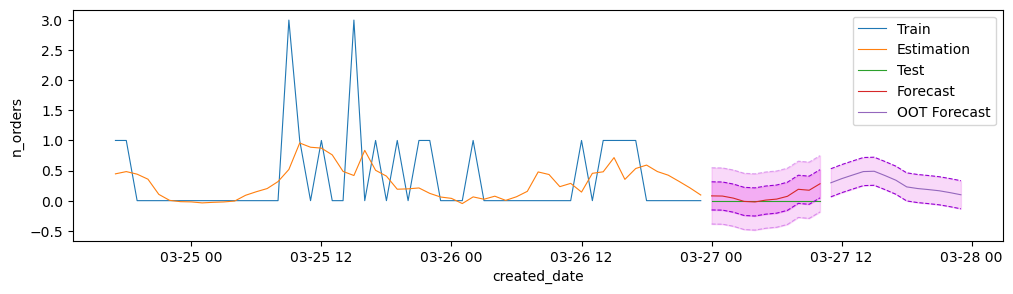

Processing account_id: ca35e88d-d191-4722-b90c-92f4a249869b, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 26ms/step - loss: 849.6451 - val_loss: 643.0737
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 848.8735 - val_loss: 642.0235
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 846.8070 - val_loss: 639.3135
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 842.5200 - val_loss: 633.9887
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 835.1788 - val_loss: 625.4123
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 824.9304 - val_loss: 613.9069
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 813.3392 - val_loss: 600.7786
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 802.2974 - val_loss: 586.6215
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 789.1558 - val_loss: 572.0155
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 777.4989 - val_loss: 557.5659
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 767.6634 - val_loss: 543.9413
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 758.8602 - val_loss: 530.4792
Ep

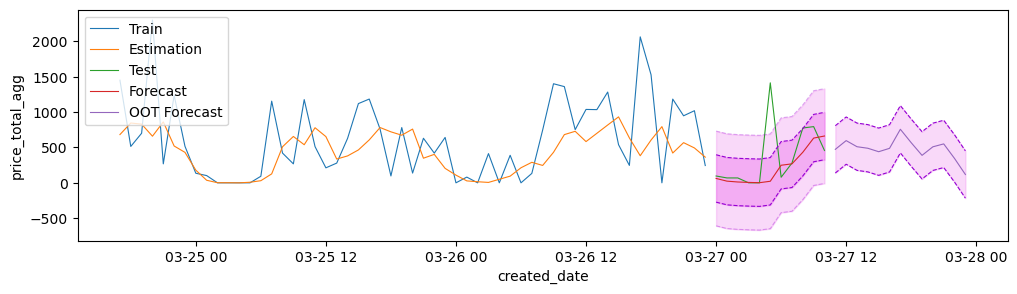

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 41ms/step - loss: 4.0571 - val_loss: 2.8350
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 3.4182 - val_loss: 2.2492
Epoch 3/1000
60/60 - 0s - 5ms/step - loss: 2.7087 - val_loss: 1.8899
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 2.4429 - val_loss: 1.7806
Epoch 5/1000
60/60 - 0s - 5ms/step - loss: 2.3748 - val_loss: 1.7633
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 2.2909 - val_loss: 1.7215
Epoch 7/1000
60/60 - 0s - 5ms/step - loss: 2.2837 - val_loss: 1.7004
Epoch 8/1000
60/60 - 0s - 5ms/step - loss: 2.2054 - val_loss: 1.6828
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 2.1681 - val_loss: 1.6869
Epoch 10/1000
60/60 - 0s - 5ms/step - loss: 2.1174 - val_loss: 1.6632
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 2.0931 - val_loss: 1.6518
Epoch 12/1000
60/60 - 0s - 4ms/step - loss: 2.0648 - val_loss: 1.6507
Epoch 13/1000
60/60 - 0s - 4ms/step - loss: 2.0993 - val_loss: 1.6352
Epoch 14/1000
60/60 - 0s - 4ms/step - loss: 2.0515 - val_loss: 1.6341


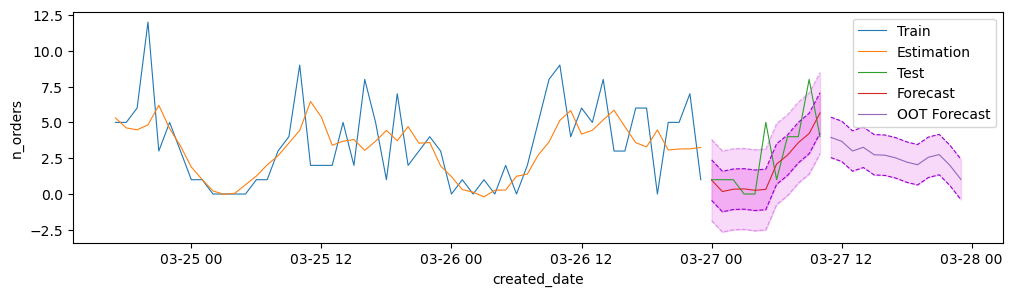

Processing account_id: c0cc925b-66c1-4b1c-b609-1bddc82ef4a4, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 41ms/step - loss: 31.7996 - val_loss: 9.7691e-04
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 31.7862 - val_loss: 5.5861e-04
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 31.7791 - val_loss: 0.0011
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 31.7749 - val_loss: 0.0012
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 31.7690 - val_loss: 6.7985e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Epoch 1/1000
61/61 - 1s - 23ms/step - loss: 31.6315 - val_loss: 0.0012
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 31.6167 - val_loss: 0.0011
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 31.6115 - val_loss: 3.7912e-05
Epoch 4/1000
61/61 - 0s - 5ms/step - loss: 31.6050 - val_loss: 9.8450e-04
Epoch 5/1000
61/61 - 0s - 4ms/step - loss: 31.6028 - val_loss: 7.2320e-04
Epoch 6/1000
61/61 - 0s - 4ms/step - loss: 31.5999 - val_loss: 7.2013e-04
1/1 ━

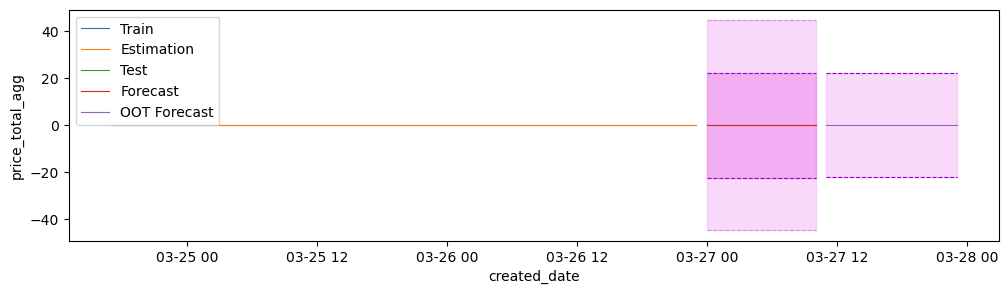

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 27ms/step - loss: 0.2716 - val_loss: 0.0059
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 0.2639 - val_loss: 7.2836e-04
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 0.2538 - val_loss: 0.0048
Epoch 4/1000
60/60 - 0s - 5ms/step - loss: 0.2488 - val_loss: 0.0018
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 0.2446 - val_loss: 2.2026e-04
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 0.2423 - val_loss: 3.7873e-04
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 0.2397 - val_loss: 3.1964e-04
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 0.2374 - val_loss: 6.2417e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Epoch 1/1000
61/61 - 2s - 30ms/step - loss: 0.2727 - val_loss: 0.0019
Epoch 2/1000
61/61 - 0s - 4ms/step - loss: 0.2576 - val_loss: 0.0032
Epoch 3/1000
61/61 - 0s - 4ms/step - loss: 0.2520 - val_loss: 0.0017
Epoch 4/1000
61/61 - 0s - 5ms/step - loss: 0.2472 - val_loss: 3.8134e-04
Epoch 5/1000
61/61 - 0s - 4ms/step - loss

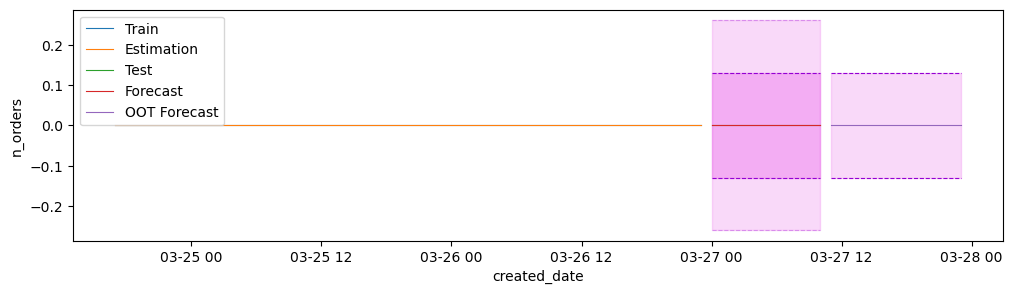

Processing account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 26ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epoch 1/1000
61/61 - 1s - 17ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/s

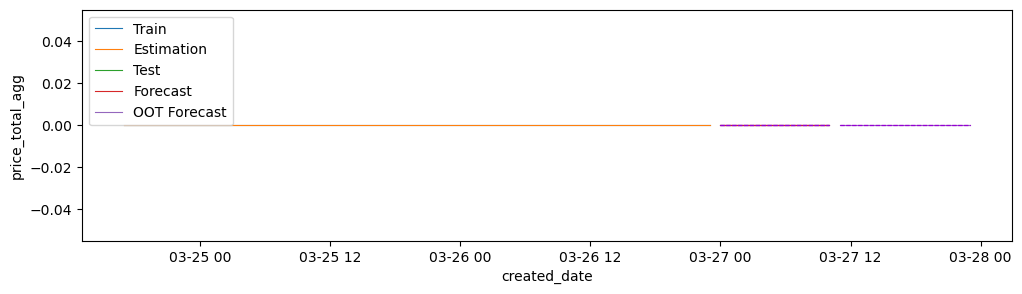

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 19ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Epoch 1/1000
61/61 - 1s - 22ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━

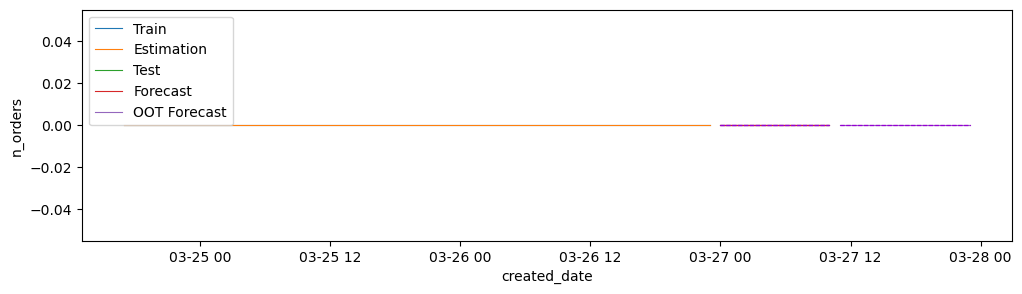

Processing account_id: ad942d1a-15ab-4a0d-83a8-ae82183ece53, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 38ms/step - loss: 870.2322 - val_loss: 1051.1471
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 866.6187 - val_loss: 1043.6575
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 856.0017 - val_loss: 1027.3604
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 837.2525 - val_loss: 1003.5811
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 811.6821 - val_loss: 973.8222
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 781.7582 - val_loss: 938.2747
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 746.1463 - val_loss: 897.3840
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 706.0175 - val_loss: 852.2897
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 664.1921 - val_loss: 803.9581
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 618.5472 - val_loss: 754.7307
Epoch 11/1000
60/60 - 0s - 6ms/step - loss: 576.5117 - val_loss: 706.7692
Epoch 12/1000
60/60 - 0s - 4ms/step - loss: 537.6967 - val_loss: 661.204

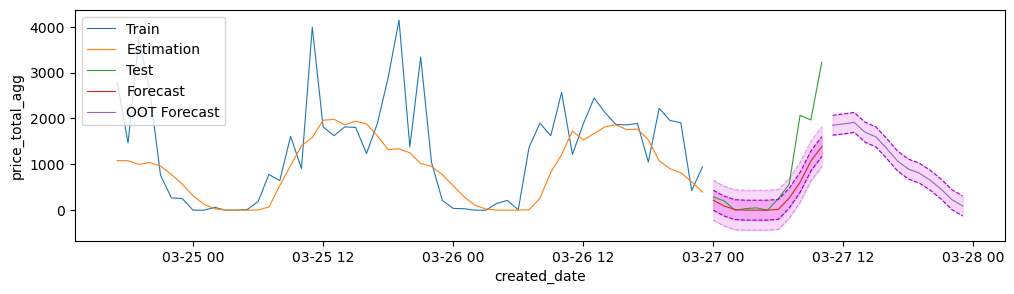

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 41ms/step - loss: 6.4267 - val_loss: 5.5620
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 3.6694 - val_loss: 2.5590
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 2.7224 - val_loss: 2.5354
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 2.6228 - val_loss: 2.5445
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 2.5969 - val_loss: 2.5709
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 2.6274 - val_loss: 2.5383
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Epoch 1/1000
61/61 - 2s - 25ms/step - loss: 6.3704 - val_loss: 5.2964
Epoch 2/1000
61/61 - 0s - 4ms/step - loss: 3.4267 - val_loss: 2.5357
Epoch 3/1000
61/61 - 0s - 5ms/step - loss: 2.6832 - val_loss: 2.5635
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 2.6603 - val_loss: 2.5240
Epoch 5/1000
61/61 - 0s - 5ms/step - loss: 2.5919 - val_loss: 2.5528
Epoch 6/1000
61/61 - 0s - 5ms/step - loss: 2.6101 - val_loss: 2.5417
Epoch 7/1000
61/61 - 0s - 3ms/step - loss: 2.5449 - val_loss: 2.5

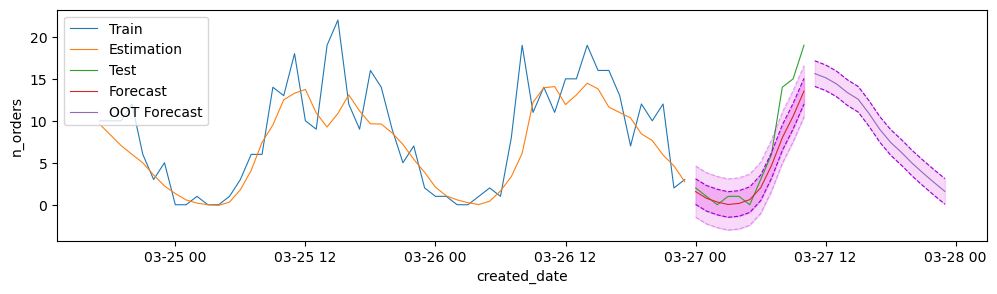

Processing account_id: 74abffac-6542-4eff-8eae-cc85463a5d02, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 39ms/step - loss: 2556.8784 - val_loss: 2884.2302
Epoch 2/1000
60/60 - 0s - 5ms/step - loss: 2553.2805 - val_loss: 2877.8047
Epoch 3/1000
60/60 - 0s - 5ms/step - loss: 2542.4741 - val_loss: 2862.7078
Epoch 4/1000
60/60 - 0s - 6ms/step - loss: 2522.9978 - val_loss: 2839.2788
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 2496.2073 - val_loss: 2808.8833
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 2462.0032 - val_loss: 2772.1194
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 2422.4192 - val_loss: 2729.3762
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 2375.7195 - val_loss: 2680.2588
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 2326.7490 - val_loss: 2625.2832
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 2268.9160 - val_loss: 2564.6304
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 2201.7974 - val_loss: 2497.5247
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 2132.3938 

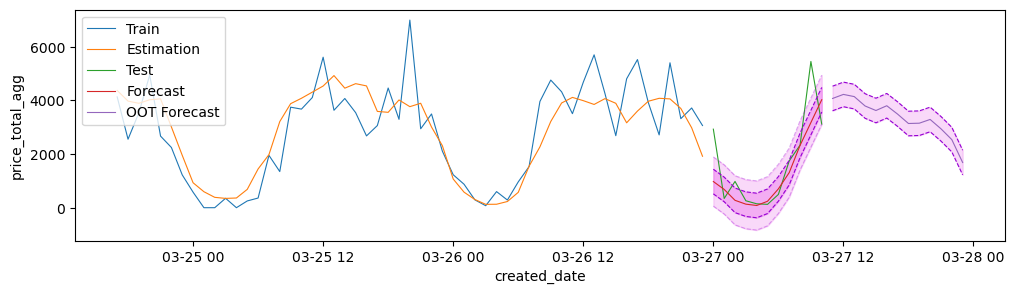

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 39ms/step - loss: 17.1810 - val_loss: 17.0279
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 13.5264 - val_loss: 10.9530
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 6.1943 - val_loss: 4.8739
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 4.9468 - val_loss: 4.7756
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 4.8084 - val_loss: 4.6708
Epoch 6/1000
60/60 - 0s - 6ms/step - loss: 4.7274 - val_loss: 4.6345
Epoch 7/1000
60/60 - 0s - 5ms/step - loss: 4.6699 - val_loss: 4.6224
Epoch 8/1000
60/60 - 0s - 5ms/step - loss: 4.6167 - val_loss: 4.5563
Epoch 9/1000
60/60 - 0s - 5ms/step - loss: 4.6472 - val_loss: 4.6561
Epoch 10/1000
60/60 - 0s - 5ms/step - loss: 4.6580 - val_loss: 4.5101
Epoch 11/1000
60/60 - 0s - 5ms/step - loss: 4.5347 - val_loss: 4.4893
Epoch 12/1000
60/60 - 0s - 5ms/step - loss: 4.5072 - val_loss: 4.4674
Epoch 13/1000
60/60 - 0s - 5ms/step - loss: 4.5747 - val_loss: 4.4530
Epoch 14/1000
60/60 - 0s - 4ms/step - loss: 4.5606 - val_loss: 4.3

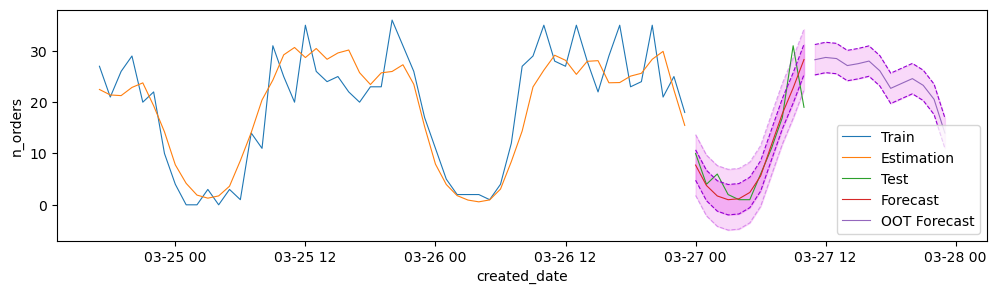

Processing account_id: 9d1296ca-9e4f-4840-b7b5-e12172acab78, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 20ms/step - loss: 246.7214 - val_loss: 224.7305
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 246.5912 - val_loss: 224.7496
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 246.2263 - val_loss: 224.7887
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 245.4625 - val_loss: 224.8414
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoch 1/1000
61/61 - 1s - 22ms/step - loss: 248.6146 - val_loss: 195.9786
Epoch 2/1000
61/61 - 0s - 4ms/step - loss: 248.5072 - val_loss: 195.9926
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 248.2555 - val_loss: 196.0305
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 247.6721 - val_loss: 196.0818
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1

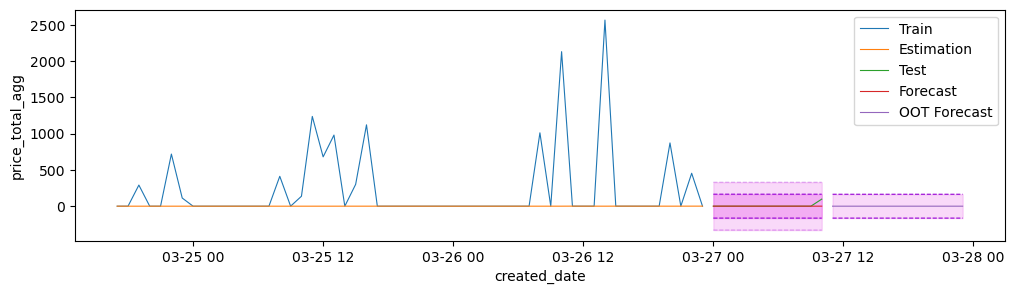

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 1.0235 - val_loss: 0.4407
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.8528 - val_loss: 0.4409
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.7459 - val_loss: 0.4390
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.7352 - val_loss: 0.4389
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 0.6963 - val_loss: 0.4377
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.6765 - val_loss: 0.4386
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 0.7803 - val_loss: 0.4373
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 0.8519 - val_loss: 0.4382
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 0.6821 - val_loss: 0.4374
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 0.6752 - val_loss: 0.4375
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Epoch 1/1000
61/61 - 1s - 16ms/step - loss: 0.9802 - val_loss: 0.4286
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 0.8269 - val_loss: 0.4288
Epoch 3/1000
61/61 - 0s - 4ms/step - loss: 0.7326 - val_loss: 0.

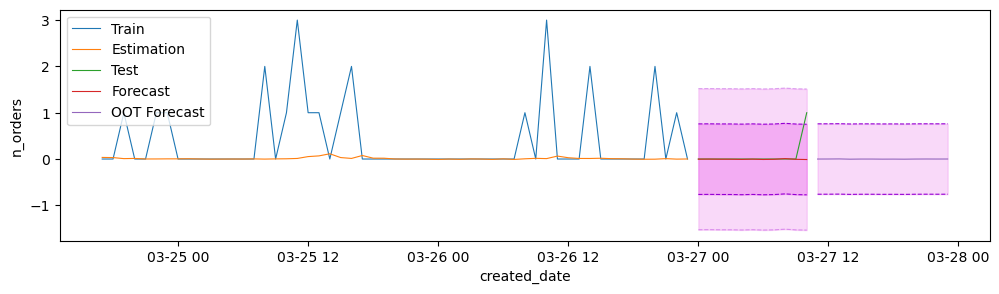

Processing account_id: 60ca8452-5b14-481f-a637-8756f527aee8, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 27ms/step - loss: 275.6753 - val_loss: 9.2762e-04
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 275.6260 - val_loss: 6.9850e-04
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 275.5435 - val_loss: 1.4979e-04
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 275.3844 - val_loss: 7.1463e-05
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 275.1119 - val_loss: 8.0056e-05
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 274.7175 - val_loss: 4.9918e-05
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 274.2500 - val_loss: 2.5516e-04
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 273.7080 - val_loss: 2.3473e-04
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 273.1779 - val_loss: 1.4703e-05
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 272.5275 - val_loss: 2.7658e-04
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 271.8425 - val_loss: 8.3114e-05
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 271.0815 -

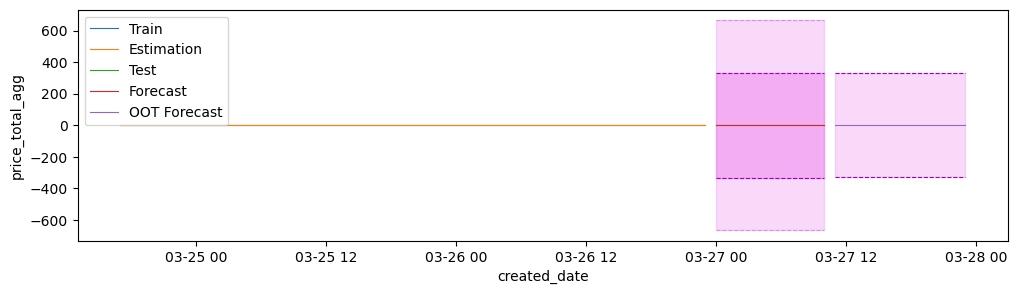

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 22ms/step - loss: 1.4176 - val_loss: 0.0014
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 1.3709 - val_loss: 3.3168e-04
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 1.3483 - val_loss: 1.9642e-04
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.3237 - val_loss: 1.8116e-04
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1.2739 - val_loss: 9.3099e-05
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1.2375 - val_loss: 2.5568e-05
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.1920 - val_loss: 2.6605e-04
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1.1545 - val_loss: 2.0431e-05
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 1.1426 - val_loss: 2.1187e-05
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 1.1120 - val_loss: 9.6125e-05
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 1.1525 - val_loss: 2.3030e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Epoch 1/1000
61/61 - 1s - 22ms/step - loss: 1.3866 - val_loss: 9.1785e-04
Epoch 2/1000
61/61 

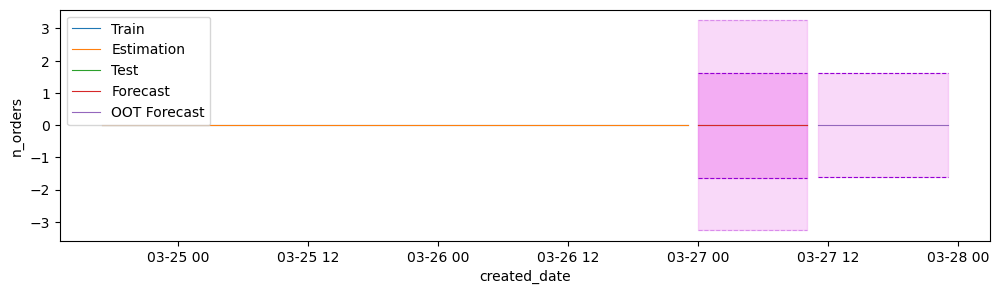

Processing account_id: 60c8f748-e29d-4fce-9e66-584117ca2baf, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 26ms/step - loss: 6656.6680 - val_loss: 8843.9727
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 6654.2114 - val_loss: 8838.0020
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 6646.5552 - val_loss: 8823.7432
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 6631.7983 - val_loss: 8801.2598
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 6610.5928 - val_loss: 8771.9482
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 6583.3335 - val_loss: 8736.1611
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 6549.5537 - val_loss: 8693.0449
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 6511.0322 - val_loss: 8643.5928
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 6467.9131 - val_loss: 8588.2656
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 6417.0190 - val_loss: 8525.9521
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 6360.5747 - val_loss: 8457.2422
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 6301.7690 

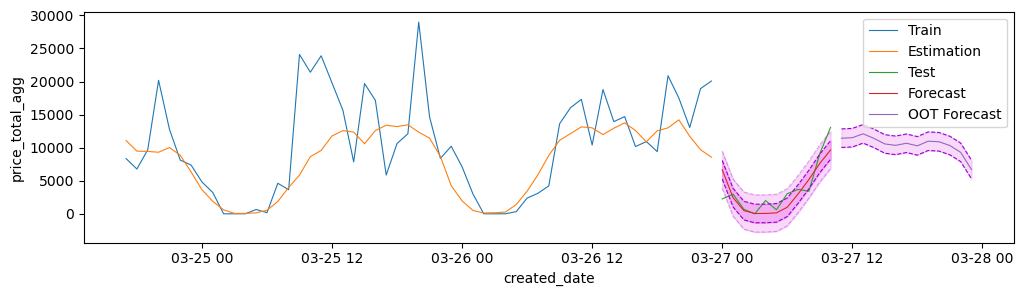

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 25ms/step - loss: 14.6581 - val_loss: 16.7379
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 11.4696 - val_loss: 9.9078
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 6.0714 - val_loss: 5.7233
Epoch 4/1000
60/60 - 0s - 6ms/step - loss: 5.2062 - val_loss: 5.5326
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 5.1770 - val_loss: 5.4850
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 5.0794 - val_loss: 5.4756
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 5.0921 - val_loss: 5.4404
Epoch 8/1000
60/60 - 0s - 5ms/step - loss: 5.0513 - val_loss: 5.4164
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 5.0514 - val_loss: 5.4005
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 5.0022 - val_loss: 5.3635
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 4.9535 - val_loss: 5.3436
Epoch 12/1000
60/60 - 0s - 4ms/step - loss: 4.8568 - val_loss: 5.3401
Epoch 13/1000
60/60 - 0s - 4ms/step - loss: 4.9064 - val_loss: 5.2978
Epoch 14/1000
60/60 - 0s - 4ms/step - loss: 4.9488 - val_loss: 5.30

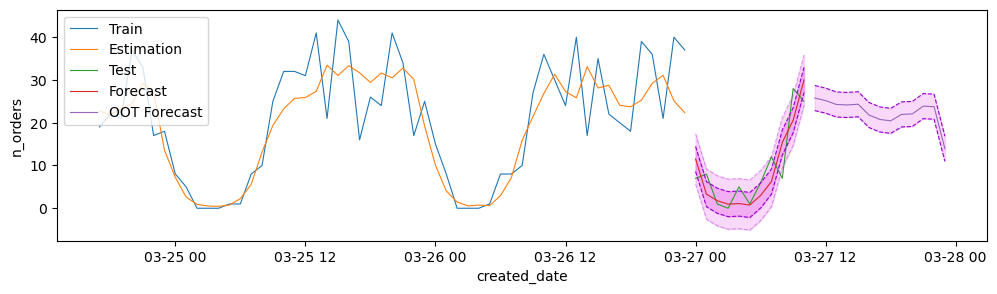

Processing account_id: 775dcad4-0733-4c22-8dbd-cd3ce344e891, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 28ms/step - loss: 1304.5642 - val_loss: 764.0297
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 1303.1902 - val_loss: 762.6372
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 1298.6981 - val_loss: 759.0810
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1290.1420 - val_loss: 752.9175
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1277.5541 - val_loss: 744.0593
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1260.4550 - val_loss: 732.4940
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1239.8864 - val_loss: 718.7834
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 1215.3970 - val_loss: 702.5884
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 1189.1801 - val_loss: 684.3840
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 1156.6095 - val_loss: 664.0178
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 1124.9700 - val_loss: 642.8354
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 1090.2323 - val_loss:

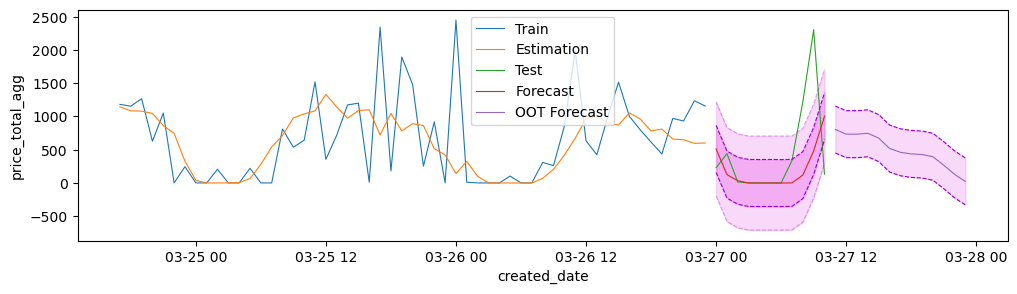

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 22ms/step - loss: 3.6991 - val_loss: 2.1138
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 2.5741 - val_loss: 1.4637
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 2.0865 - val_loss: 1.4069
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 2.0380 - val_loss: 1.4033
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1.9941 - val_loss: 1.3897
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1.9706 - val_loss: 1.3807
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.9098 - val_loss: 1.3760
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1.9010 - val_loss: 1.3743
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 1.8731 - val_loss: 1.3698
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 1.8778 - val_loss: 1.3618
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 1.8499 - val_loss: 1.3635
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 1.8446 - val_loss: 1.3621
Epoch 13/1000
60/60 - 0s - 6ms/step - loss: 1.8548 - val_loss: 1.3676
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59m

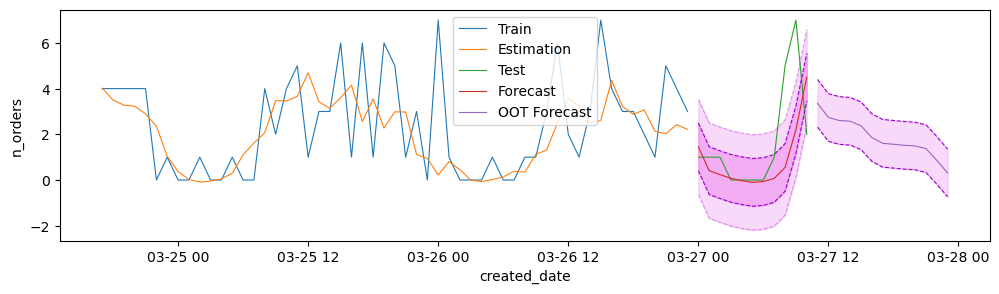

Processing account_id: 92f116fe-5818-41db-9eb5-87445ad3818e, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 17ms/step - loss: 653.9665 - val_loss: 675.5786
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 652.6388 - val_loss: 672.6251
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 648.4406 - val_loss: 664.8126
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 639.9343 - val_loss: 651.6618
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 627.3110 - val_loss: 634.1107
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 611.0498 - val_loss: 614.2310
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 592.1069 - val_loss: 592.9808
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 572.4925 - val_loss: 572.1982
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 553.6830 - val_loss: 554.8663
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 536.5154 - val_loss: 540.4935
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 523.1265 - val_loss: 528.5327
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 510.0296 - val_loss: 517.5519
Ep

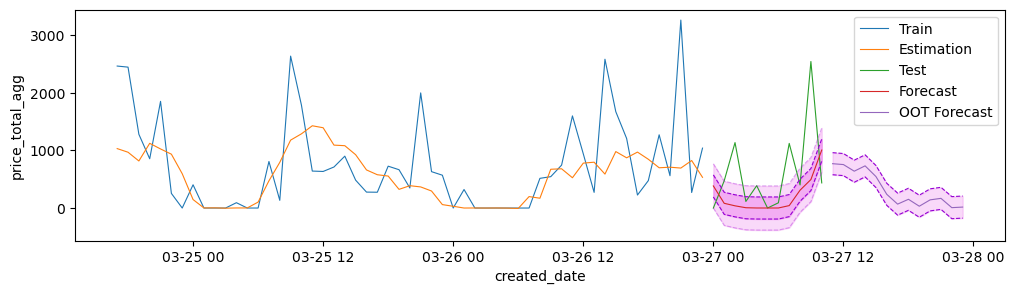

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 39ms/step - loss: 1.7759 - val_loss: 1.4313
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 1.2948 - val_loss: 1.2248
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 1.2548 - val_loss: 1.2104
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.2220 - val_loss: 1.2024
Epoch 5/1000
60/60 - 0s - 5ms/step - loss: 1.2164 - val_loss: 1.2023
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 1.2038 - val_loss: 1.2056
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.1925 - val_loss: 1.2025
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 1.1934 - val_loss: 1.2055
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Epoch 1/1000
61/61 - 2s - 32ms/step - loss: 1.7814 - val_loss: 1.4188
Epoch 2/1000
61/61 - 0s - 4ms/step - loss: 1.2934 - val_loss: 1.2127
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 1.2459 - val_loss: 1.1968
Epoch 4/1000
61/61 - 0s - 4ms/step - loss: 1.2348 - val_loss: 1.1978
Epoch 5/1000
61/61 - 0s - 4ms/step - loss: 1.1930 - val_loss: 1.1

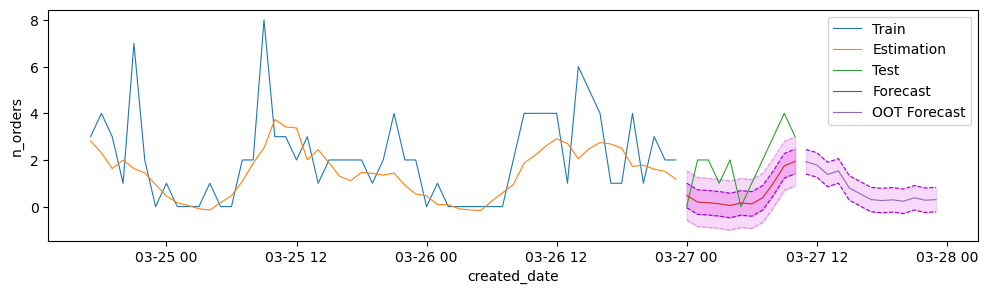

Processing account_id: 6276b87c-ebb2-11ed-a05b-0242ac120003, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 3s - 50ms/step - loss: 495.8722 - val_loss: 588.2388
Epoch 2/1000
60/60 - 0s - 6ms/step - loss: 494.5570 - val_loss: 585.9033
Epoch 3/1000
60/60 - 0s - 5ms/step - loss: 490.3864 - val_loss: 579.6380
Epoch 4/1000
60/60 - 0s - 5ms/step - loss: 481.5319 - val_loss: 568.3874
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 468.0368 - val_loss: 552.3205
Epoch 6/1000
60/60 - 0s - 6ms/step - loss: 450.5243 - val_loss: 531.8066
Epoch 7/1000
60/60 - 0s - 5ms/step - loss: 429.2787 - val_loss: 507.7904
Epoch 8/1000
60/60 - 0s - 5ms/step - loss: 406.6188 - val_loss: 481.7618
Epoch 9/1000
60/60 - 0s - 5ms/step - loss: 382.0988 - val_loss: 454.2189
Epoch 10/1000
60/60 - 0s - 6ms/step - loss: 359.6166 - val_loss: 427.1997
Epoch 11/1000
60/60 - 0s - 6ms/step - loss: 339.8121 - val_loss: 402.6745
Epoch 12/1000
60/60 - 0s - 6ms/step - loss: 323.1366 - val_loss: 380.8624
Ep

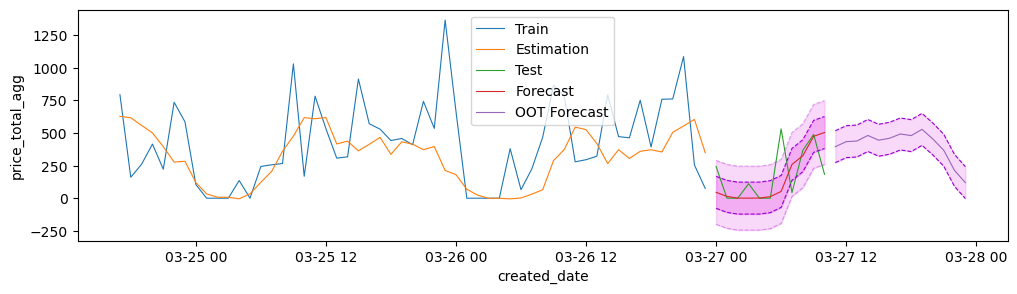

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 39ms/step - loss: 3.7852 - val_loss: 3.6064
Epoch 2/1000
60/60 - 0s - 5ms/step - loss: 2.5097 - val_loss: 2.0676
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 1.9484 - val_loss: 1.8335
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 1.9192 - val_loss: 1.8006
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1.8690 - val_loss: 1.7739
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 1.8477 - val_loss: 1.7734
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.8599 - val_loss: 1.7717
Epoch 8/1000
60/60 - 0s - 7ms/step - loss: 1.8546 - val_loss: 1.7611
Epoch 9/1000
60/60 - 0s - 5ms/step - loss: 1.8297 - val_loss: 1.7573
Epoch 10/1000
60/60 - 0s - 5ms/step - loss: 1.8064 - val_loss: 1.7544
Epoch 11/1000
60/60 - 0s - 5ms/step - loss: 1.8159 - val_loss: 1.7405
Epoch 12/1000
60/60 - 0s - 5ms/step - loss: 1.8039 - val_loss: 1.7401
Epoch 13/1000
60/60 - 0s - 4ms/step - loss: 1.8103 - val_loss: 1.7428
Epoch 14/1000
60/60 - 0s - 5ms/step - loss: 1.8039 - val_loss: 1.7274


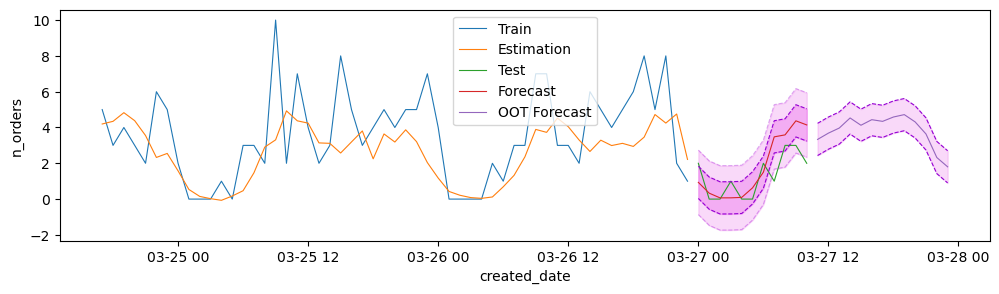

Processing account_id: 50409b57-b000-43d5-9358-44c3081c4132, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 3s - 53ms/step - loss: 284.4244 - val_loss: 467.9330
Epoch 2/1000
60/60 - 0s - 6ms/step - loss: 284.3419 - val_loss: 467.6425
Epoch 3/1000
60/60 - 0s - 6ms/step - loss: 284.2009 - val_loss: 467.0761
Epoch 4/1000
60/60 - 0s - 5ms/step - loss: 283.9314 - val_loss: 466.0200
Epoch 5/1000
60/60 - 0s - 6ms/step - loss: 283.4978 - val_loss: 464.3428
Epoch 6/1000
60/60 - 0s - 5ms/step - loss: 282.8868 - val_loss: 462.0469
Epoch 7/1000
60/60 - 0s - 6ms/step - loss: 281.9856 - val_loss: 459.0494
Epoch 8/1000
60/60 - 0s - 6ms/step - loss: 281.1339 - val_loss: 455.5233
Epoch 9/1000
60/60 - 0s - 6ms/step - loss: 279.7529 - val_loss: 451.3430
Epoch 10/1000
60/60 - 0s - 6ms/step - loss: 278.3268 - val_loss: 447.0515
Epoch 11/1000
60/60 - 0s - 5ms/step - loss: 277.0416 - val_loss: 442.6730
Epoch 12/1000
60/60 - 0s - 6ms/step - loss: 275.5500 - val_loss: 438.1232
Ep

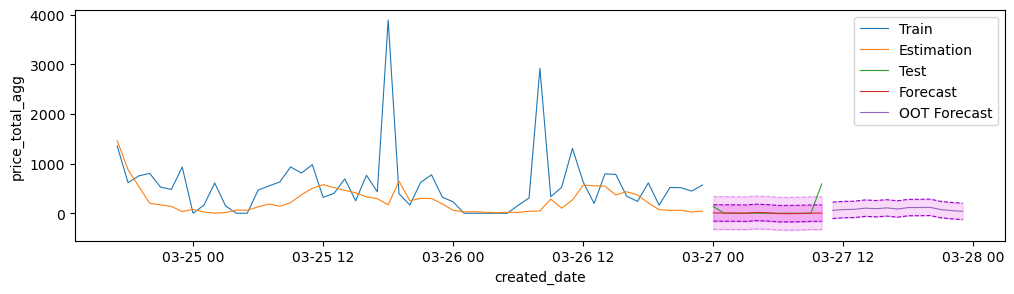

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 37ms/step - loss: 1.1768 - val_loss: 1.6755
Epoch 2/1000
60/60 - 0s - 5ms/step - loss: 1.1037 - val_loss: 1.4983
Epoch 3/1000
60/60 - 0s - 5ms/step - loss: 1.0363 - val_loss: 1.3360
Epoch 4/1000
60/60 - 0s - 6ms/step - loss: 0.9722 - val_loss: 1.2860
Epoch 5/1000
60/60 - 0s - 5ms/step - loss: 0.9457 - val_loss: 1.2339
Epoch 6/1000
60/60 - 0s - 6ms/step - loss: 0.9312 - val_loss: 1.2214
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 0.9319 - val_loss: 1.1894
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 0.9222 - val_loss: 1.1787
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 0.9046 - val_loss: 1.1466
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 0.9190 - val_loss: 1.1639
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 0.9054 - val_loss: 1.1452
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 0.8999 - val_loss: 1.1598
Epoch 13/1000
60/60 - 0s - 5ms/step - loss: 0.9062 - val_loss: 1.1308
Epoch 14/1000
60/60 - 0s - 2ms/step - loss: 0.8972 - val_loss: 1.1428


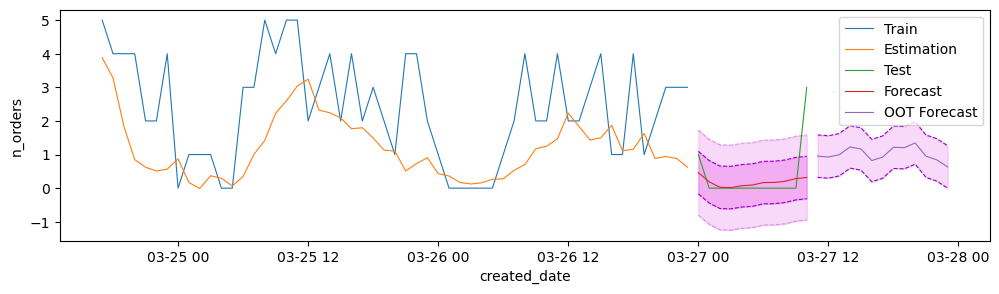

Processing account_id: 789ff5c4-21d8-4ed3-ab64-8b46cf2eba9b, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 16ms/step - loss: 255.2509 - val_loss: 209.7446
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 255.0980 - val_loss: 209.5988
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 254.7931 - val_loss: 209.3031
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 254.2419 - val_loss: 208.7776
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 253.2856 - val_loss: 207.9386
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 251.8889 - val_loss: 206.6907
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 250.1254 - val_loss: 205.0524
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 248.1242 - val_loss: 202.9741
Epoch 9/1000
60/60 - 0s - 5ms/step - loss: 245.6308 - val_loss: 200.5058
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 243.0733 - val_loss: 197.6736
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 240.1252 - val_loss: 194.5497
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 237.1686 - val_loss: 191.3316
Ep

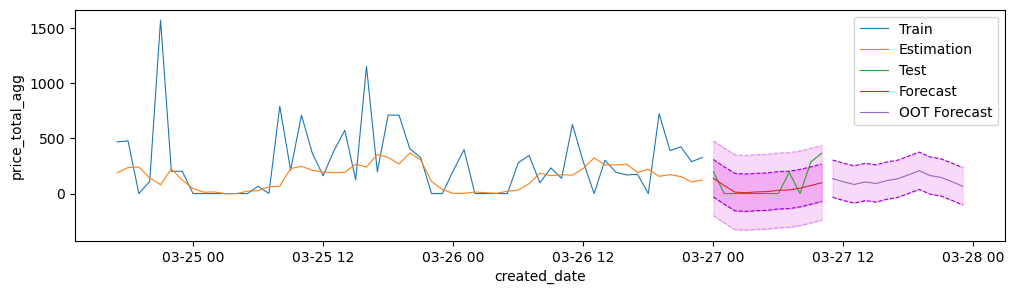

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 37ms/step - loss: 2.0695 - val_loss: 1.3341
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 1.9848 - val_loss: 1.2358
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 1.8771 - val_loss: 1.1033
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 1.8084 - val_loss: 1.0529
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 1.7910 - val_loss: 1.0364
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1.7384 - val_loss: 1.0127
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.7386 - val_loss: 0.9930
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 1.6905 - val_loss: 0.9772
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 1.6681 - val_loss: 0.9689
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 1.6588 - val_loss: 0.9615
Epoch 11/1000
60/60 - 0s - 5ms/step - loss: 1.6345 - val_loss: 0.9589
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 1.6192 - val_loss: 0.9562
Epoch 13/1000
60/60 - 0s - 4ms/step - loss: 1.6100 - val_loss: 0.9556
Epoch 14/1000
60/60 - 0s - 4ms/step - loss: 1.6109 - val_loss: 0.9558


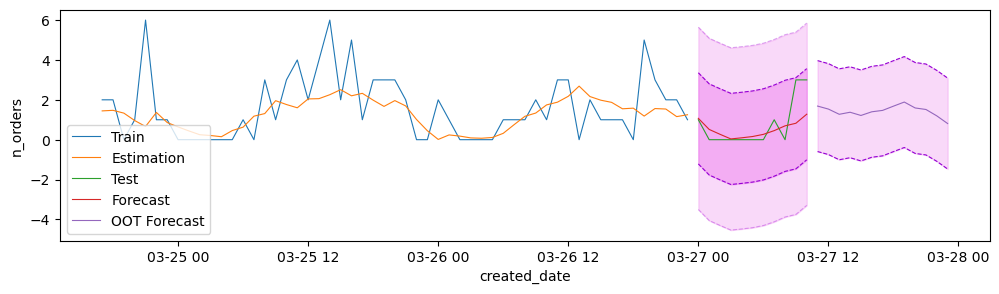

Processing account_id: d639773a-df2c-421e-ac87-6918a754572f, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 20ms/step - loss: 447.6579 - val_loss: 765.9495
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 447.6360 - val_loss: 765.9293
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 447.6060 - val_loss: 765.8726
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 447.5735 - val_loss: 765.8091
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 447.5172 - val_loss: 765.6631
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 447.4389 - val_loss: 765.5187
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 447.2849 - val_loss: 765.3015
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 447.1419 - val_loss: 765.0007
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 446.9542 - val_loss: 764.6841
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 446.7111 - val_loss: 764.2088
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 446.4433 - val_loss: 763.8516
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 446.1254 - val_loss: 763.1572
Ep

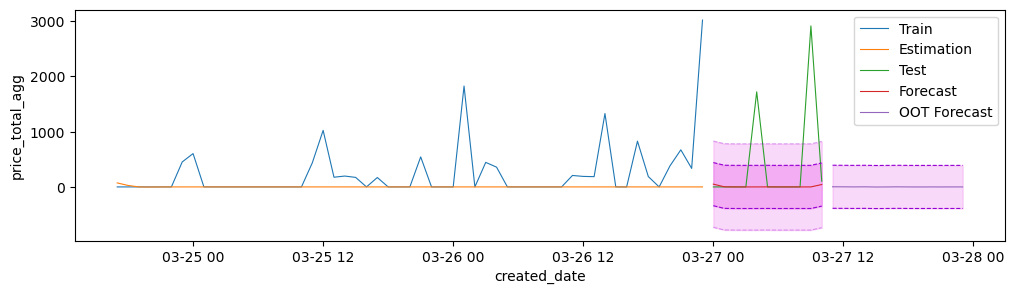

Processing column: n_orders
Epoch 1/1000
60/60 - 3s - 45ms/step - loss: 2.5210 - val_loss: 1.2165
Epoch 2/1000
60/60 - 0s - 5ms/step - loss: 2.4967 - val_loss: 1.2161
Epoch 3/1000
60/60 - 0s - 5ms/step - loss: 2.4745 - val_loss: 1.2138
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 2.4359 - val_loss: 1.2125
Epoch 5/1000
60/60 - 0s - 5ms/step - loss: 2.3696 - val_loss: 1.2091
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 2.2672 - val_loss: 1.2059
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 2.1965 - val_loss: 1.2011
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 2.1127 - val_loss: 1.1991
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 2.0641 - val_loss: 1.1911
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 2.0653 - val_loss: 1.1920
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 2.0212 - val_loss: 1.1821
Epoch 12/1000
60/60 - 0s - 5ms/step - loss: 2.0184 - val_loss: 1.1850
Epoch 13/1000
60/60 - 0s - 4ms/step - loss: 1.8976 - val_loss: 1.1758
Epoch 14/1000
60/60 - 0s - 4ms/step - loss: 1.8691 - val_loss: 1.1765


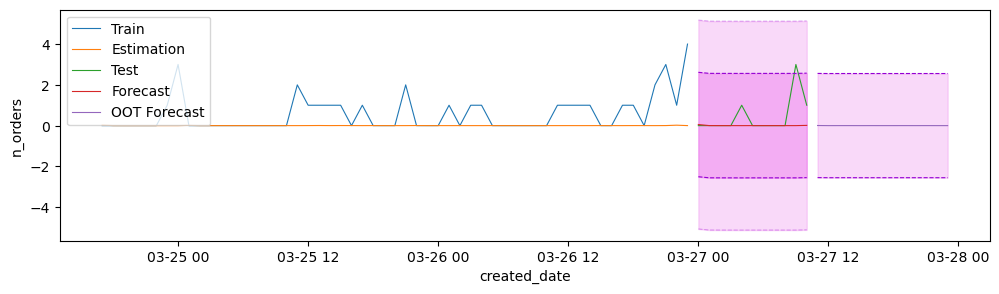

Processing account_id: f4471620-212b-4991-98d3-b498835d0c29, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 21ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Epoch 1/1000
61/61 - 1s - 22ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/st

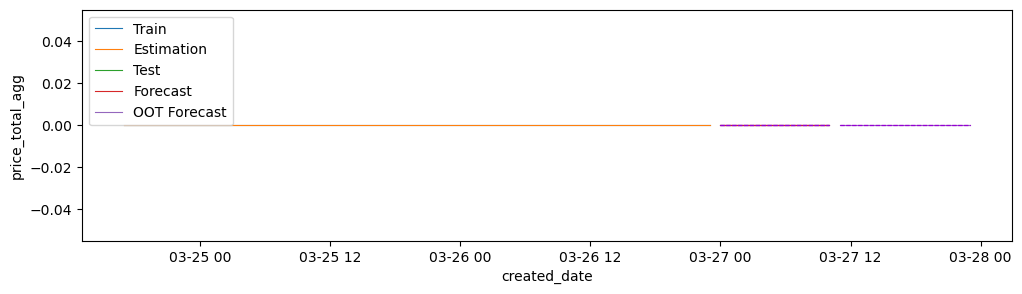

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 27ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Epoch 1/1000
61/61 - 1s - 20ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 5ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 5ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━

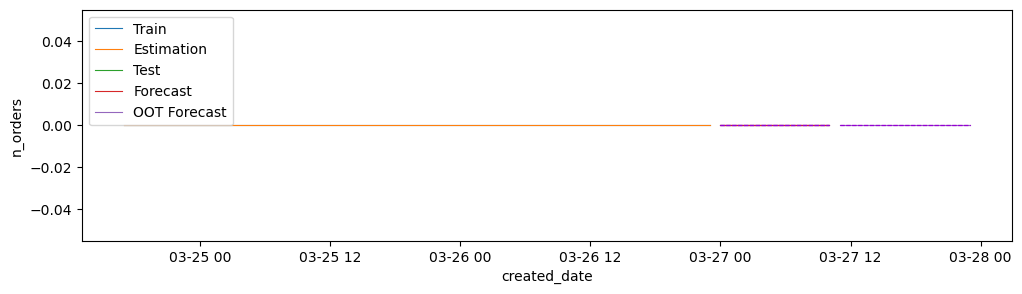

Processing account_id: 9d39683a-47b3-4a18-942d-f1d741a47e8c, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 4s - 61ms/step - loss: 45589.5117 - val_loss: 60534.6758
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 45586.0234 - val_loss: 60526.9688
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 45576.1797 - val_loss: 60510.1445
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 45558.5859 - val_loss: 60484.2148
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 45532.8164 - val_loss: 60449.4180
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 45500.2695 - val_loss: 60406.4844
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 45458.9375 - val_loss: 60355.0234
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 45411.6914 - val_loss: 60295.1875
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 45357.6094 - val_loss: 60227.6719
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 45294.0000 - val_loss: 60153.0039
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 45225.3086 - val_loss: 60071.0664
Epoch 12/1000
60/60 - 0s - 3ms/s

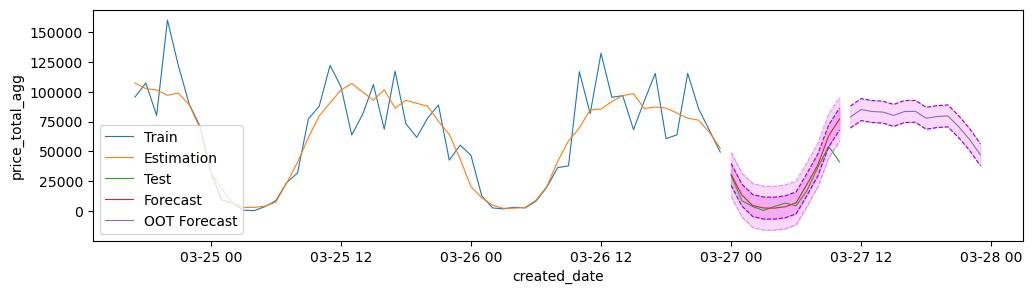

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 27ms/step - loss: 71.1444 - val_loss: 76.8198
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 67.7496 - val_loss: 70.4818
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 59.4466 - val_loss: 57.6876
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 45.3547 - val_loss: 38.0284
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 27.1778 - val_loss: 16.2059
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 18.0685 - val_loss: 12.6704
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 17.4881 - val_loss: 12.4135
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 16.5110 - val_loss: 12.2283
Epoch 9/1000
60/60 - 0s - 5ms/step - loss: 16.4391 - val_loss: 12.0054
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 16.3665 - val_loss: 11.9319
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 16.3326 - val_loss: 11.7046
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 16.0247 - val_loss: 11.5605
Epoch 13/1000
60/60 - 0s - 4ms/step - loss: 15.8466 - val_loss: 11.5534
Epoch 14/1000
60/60 - 0s - 4ms/step - loss: 

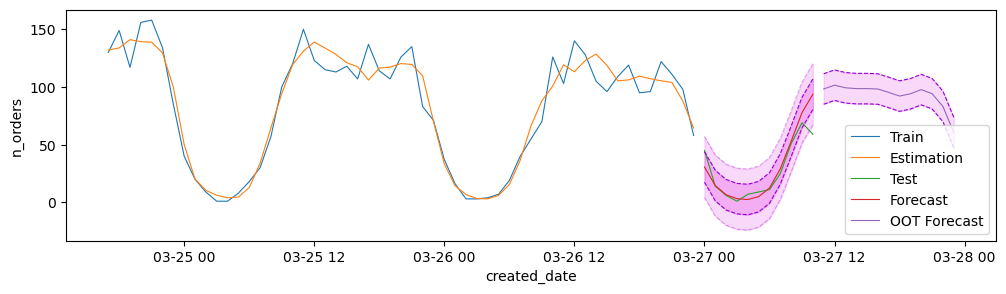

Processing account_id: 7db6eaca-fe22-41d7-bfb8-1fdde880feb8, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 287.7747 - val_loss: 245.3929
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 287.7202 - val_loss: 245.3391
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 287.6373 - val_loss: 245.2570
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 287.4674 - val_loss: 245.1367
Epoch 5/1000
60/60 - 0s - 6ms/step - loss: 287.1999 - val_loss: 244.9722
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 286.8499 - val_loss: 244.7698
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 286.4980 - val_loss: 244.5150
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 286.0852 - val_loss: 244.2013
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 285.6114 - val_loss: 243.8272
Epoch 10/1000
60/60 - 0s - 5ms/step - loss: 285.1613 - val_loss: 243.3923
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 284.5981 - val_loss: 242.8828
Epoch 12/1000
60/60 - 0s - 4ms/step - loss: 284.1211 - val_loss: 242.3153
Ep

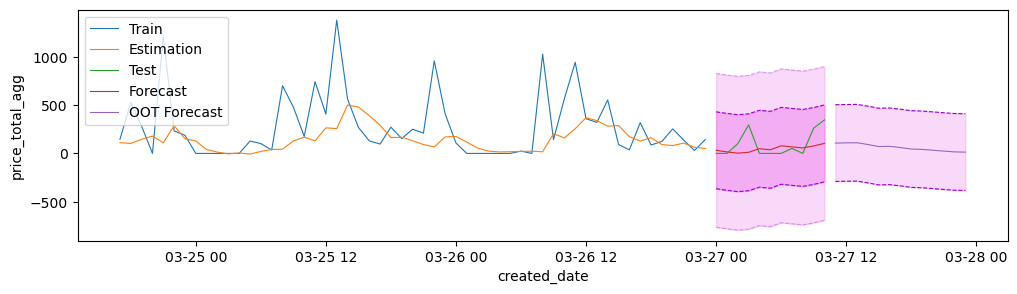

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 17ms/step - loss: 1.3008 - val_loss: 2.1091
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 1.1723 - val_loss: 1.8167
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 1.0616 - val_loss: 1.6834
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.9869 - val_loss: 1.5761
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 0.9632 - val_loss: 1.5486
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.9417 - val_loss: 1.5402
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 0.9394 - val_loss: 1.4852
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 0.9381 - val_loss: 1.4976
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 0.9230 - val_loss: 1.4466
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 0.9190 - val_loss: 1.4279
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 0.9081 - val_loss: 1.4135
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 0.9083 - val_loss: 1.4030
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 0.9084 - val_loss: 1.3831
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 0.8977 - val_loss: 1.3955


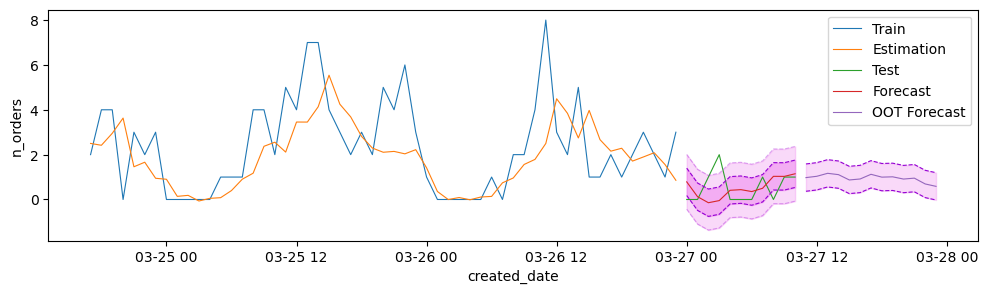

Processing account_id: adc6fb62-09e7-44fd-a619-f787ecfd140b, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 899.6204 - val_loss: 753.3125
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 897.9113 - val_loss: 751.3353
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 892.6035 - val_loss: 746.1376
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 882.3391 - val_loss: 737.1082
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 866.3706 - val_loss: 724.2766
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 845.8969 - val_loss: 708.2654
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 821.5858 - val_loss: 690.1879
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 795.1349 - val_loss: 670.1475
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 767.2308 - val_loss: 651.6130
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 739.6885 - val_loss: 633.8656
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 713.0451 - val_loss: 616.3245
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 689.0622 - val_loss: 600.3713
Ep

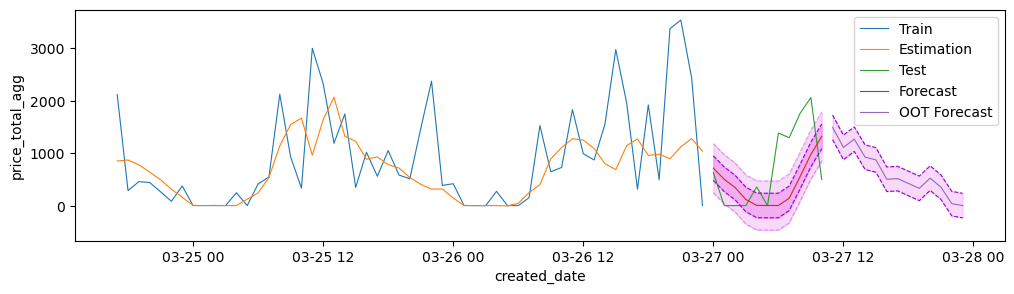

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 3.1787 - val_loss: 2.1518
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 2.0785 - val_loss: 1.6037
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1.8352 - val_loss: 1.5812
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 1.7581 - val_loss: 1.5771
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 1.7736 - val_loss: 1.5684
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 1.7487 - val_loss: 1.5673
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 1.7262 - val_loss: 1.5697
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 1.7084 - val_loss: 1.5771
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 1.7124 - val_loss: 1.5682
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epoch 1/1000
61/61 - 1s - 12ms/step - loss: 3.1215 - val_loss: 2.1694
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 2.0314 - val_loss: 1.6441
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 1.7999 - val_loss: 1.6202
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 1.7678 - val_loss: 1.6

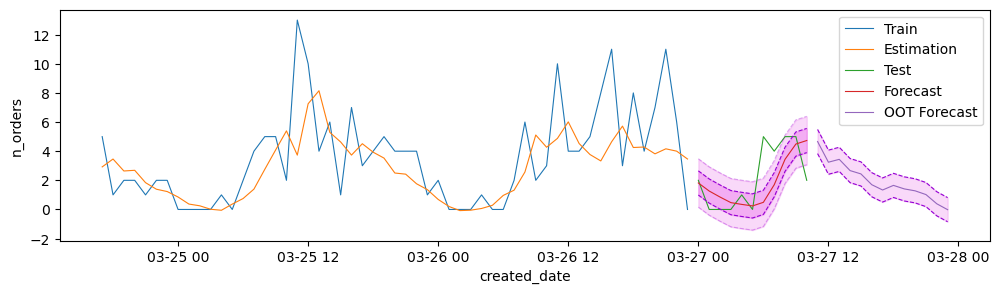

Processing account_id: 173e2b27-8bc6-44d1-b581-a1913d6b1894, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 6369.0234 - val_loss: 5040.1484
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 6366.2827 - val_loss: 5036.6011
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 6358.5977 - val_loss: 5028.3994
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 6345.1401 - val_loss: 5015.1084
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 6324.7700 - val_loss: 4996.5576
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 6298.2061 - val_loss: 4973.0571
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 6266.2905 - val_loss: 4944.7275
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 6226.7168 - val_loss: 4910.9805
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 6182.2231 - val_loss: 4872.6982
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 6131.8652 - val_loss: 4829.7998
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 6076.4839 - val_loss: 4782.4072
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 6015.9429 

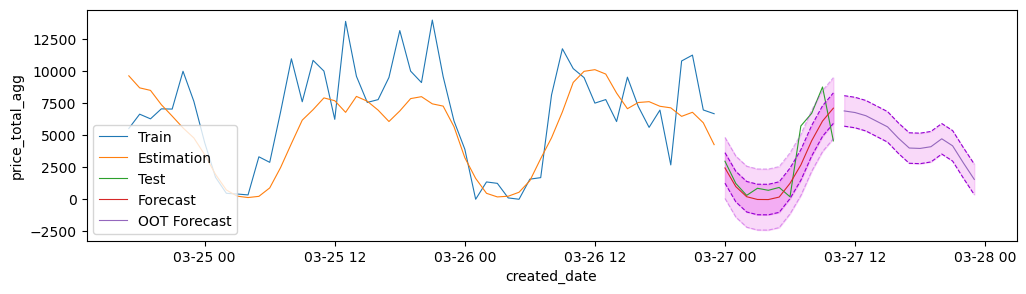

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 16ms/step - loss: 16.0354 - val_loss: 12.8456
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 14.2018 - val_loss: 10.2904
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 9.3756 - val_loss: 5.2913
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 5.5849 - val_loss: 4.4161
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 5.3486 - val_loss: 4.3364
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 5.1868 - val_loss: 4.2976
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 5.1328 - val_loss: 4.2416
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 5.2386 - val_loss: 4.1951
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 5.0389 - val_loss: 4.1840
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 4.9722 - val_loss: 4.1429
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 5.0448 - val_loss: 4.1023
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 4.8462 - val_loss: 4.0939
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 4.7138 - val_loss: 4.0681
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 4.8373 - val_loss: 4.0

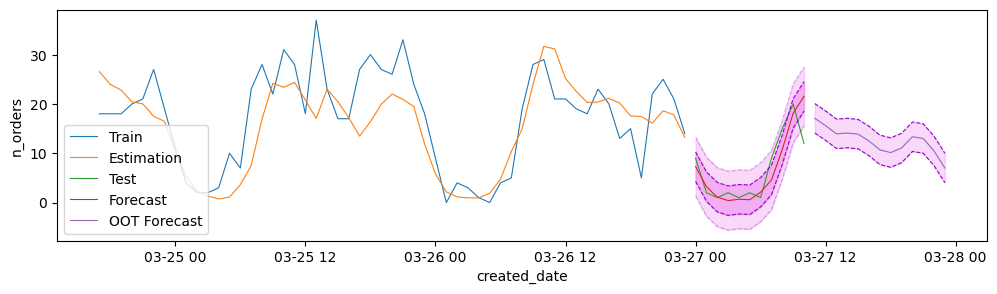

Processing account_id: 478cd985-f4fc-45b4-ac71-bf78cf11e07b, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 29ms/step - loss: 1007.8938 - val_loss: 561.7408
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 1006.7586 - val_loss: 560.9542
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 1003.2416 - val_loss: 558.8379
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 996.1135 - val_loss: 554.9727
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 984.7692 - val_loss: 549.2177
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 969.4819 - val_loss: 541.6961
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 950.3648 - val_loss: 532.5233
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 927.3407 - val_loss: 522.0989
Epoch 9/1000
60/60 - 0s - 5ms/step - loss: 901.2024 - val_loss: 510.6128
Epoch 10/1000
60/60 - 0s - 5ms/step - loss: 874.7667 - val_loss: 498.3196
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 846.1757 - val_loss: 485.6291
Epoch 12/1000
60/60 - 0s - 4ms/step - loss: 818.0085 - val_loss: 473.5125

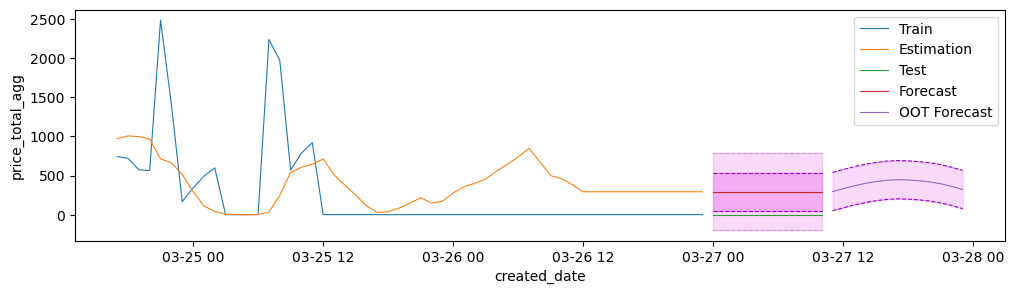

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 40ms/step - loss: 4.7151 - val_loss: 2.1176
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 3.9114 - val_loss: 1.8231
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 2.8480 - val_loss: 1.6157
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 2.4666 - val_loss: 1.5463
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 2.3755 - val_loss: 1.4982
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 2.3149 - val_loss: 1.4568
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 2.2493 - val_loss: 1.4572
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 2.2270 - val_loss: 1.4410
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 2.2161 - val_loss: 1.4249
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 2.2070 - val_loss: 1.4115
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 2.1942 - val_loss: 1.3950
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 2.1767 - val_loss: 1.4083
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 2.1657 - val_loss: 1.3995
Epoch 14/1000
60/60 - 0s - 2ms/step - loss: 2.1445 - val_loss: 1.3885


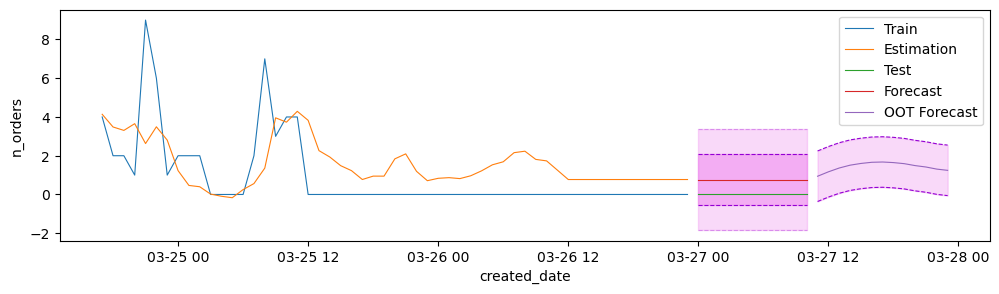

Processing account_id: 2058f680-aace-4b31-aed4-f34397b75096, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 0.0575 - val_loss: 7.9480e-06
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0593 - val_loss: 1.0357e-04
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.0561 - val_loss: 1.6445e-05
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.0566 - val_loss: 1.2732e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoch 1/1000
61/61 - 1s - 13ms/step - loss: 0.0594 - val_loss: 9.7143e-06
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0597 - val_loss: 5.8161e-05
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.0600 - val_loss: 1.8510e-05
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 0.0542 - val_loss: 2.5421e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1

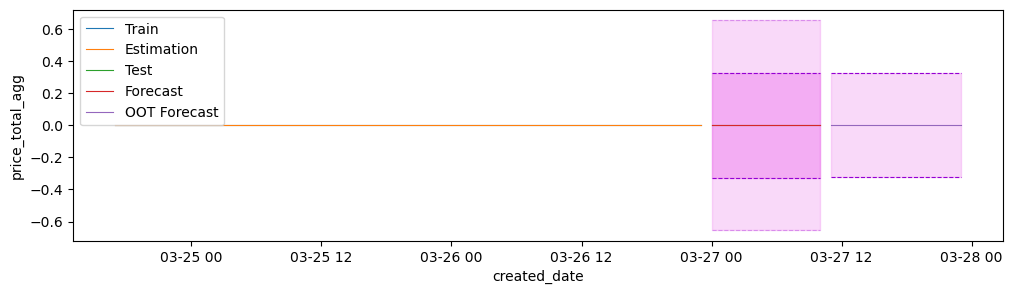

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 0.0221 - val_loss: 1.2035e-05
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0244 - val_loss: 4.2944e-05
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.0163 - val_loss: 4.6196e-05
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.0147 - val_loss: 7.5847e-05
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Epoch 1/1000
61/61 - 1s - 14ms/step - loss: 0.0211 - val_loss: 2.0467e-04
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0228 - val_loss: 3.2629e-05
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.0175 - val_loss: 5.3863e-05
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 0.0183 - val_loss: 2.6172e-04
Epoch 5/1000
61/61 - 0s - 2ms/step - loss: 0.0157 - val_loss: 2.0584e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━

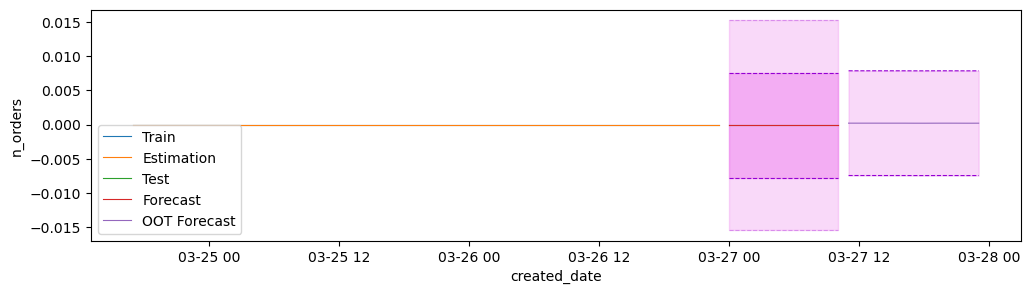

Processing account_id: 8fa00df1-38eb-426f-81a6-1185983e14cb, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 81.4485 - val_loss: 7.1749e-04
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 81.4333 - val_loss: 8.9023e-04
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 81.4255 - val_loss: 1.5904e-04
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 81.4164 - val_loss: 5.4420e-05
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 81.4071 - val_loss: 3.4724e-04
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 81.3972 - val_loss: 3.1898e-04
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 81.3809 - val_loss: 2.7657e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Epoch 1/1000
61/61 - 1s - 11ms/step - loss: 81.0219 - val_loss: 6.9919e-04
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 81.0092 - val_loss: 9.6855e-04
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 81.0029 - val_loss: 1.2658e-05
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 80.9966 - val_loss: 

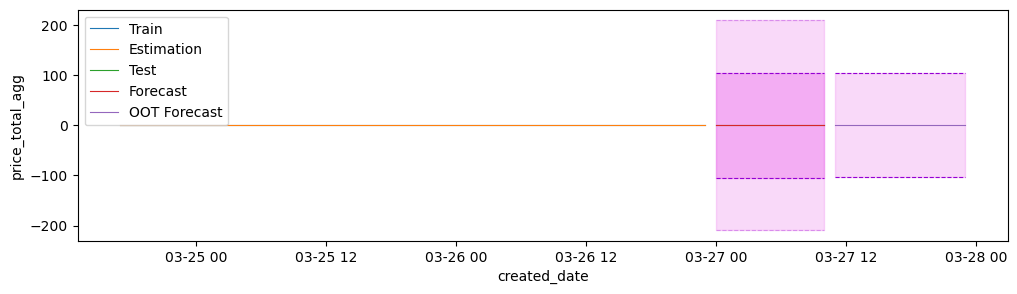

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 1.3446 - val_loss: 2.9707e-04
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1.3311 - val_loss: 3.3572e-04
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1.3241 - val_loss: 2.7939e-04
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 1.3135 - val_loss: 3.6244e-04
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 1.3074 - val_loss: 1.9460e-04
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 1.2938 - val_loss: 1.5029e-05
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.2837 - val_loss: 3.5228e-04
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 1.2722 - val_loss: 2.4787e-04
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 1.2551 - val_loss: 1.5238e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoch 1/1000
61/61 - 1s - 15ms/step - loss: 1.3432 - val_loss: 0.0018
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 1.3269 - val_loss: 1.5246e-04
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 1.3192 - val_loss: 1.4491e-04
Epoch 4/1000
61/61 - 

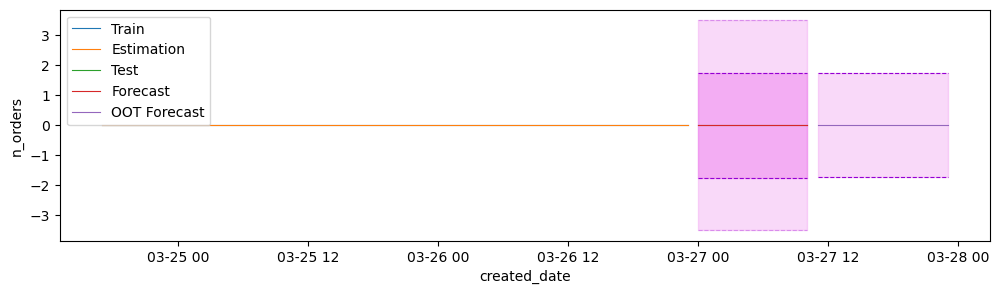

Processing account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 34637.4961 - val_loss: 30492.2930
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 34632.0781 - val_loss: 30483.2422
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 34617.5508 - val_loss: 30464.3848
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 34593.4727 - val_loss: 30436.5781
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 34559.9609 - val_loss: 30400.5723
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 34518.3633 - val_loss: 30357.0371
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 34470.9258 - val_loss: 30305.9023
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 34411.9023 - val_loss: 30246.6582
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 34346.4219 - val_loss: 30180.5078
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 34274.3516 - val_loss: 30106.5098
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 34191.6680 - val_loss: 30024.2168
Epoch 12/1000
60/60 - 0s - 2ms/s

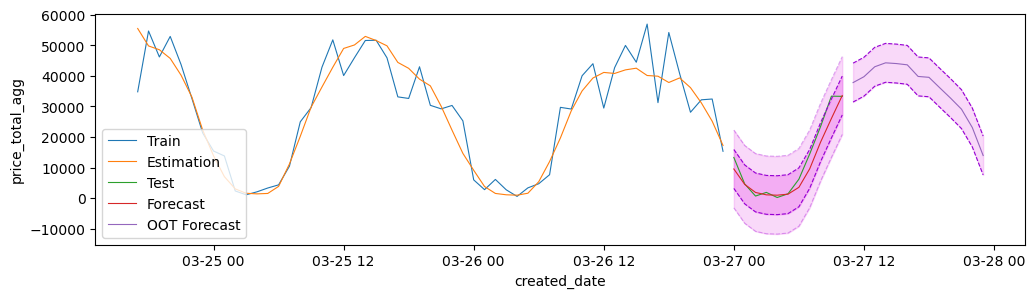

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 27ms/step - loss: 110.4250 - val_loss: 93.4741
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 106.4425 - val_loss: 87.7771
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 97.4408 - val_loss: 76.7460
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 82.0907 - val_loss: 59.3547
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 60.9776 - val_loss: 36.9603
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 40.3834 - val_loss: 19.4187
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 31.4277 - val_loss: 15.6701
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 29.8122 - val_loss: 14.8285
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 29.1698 - val_loss: 14.2820
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 28.7182 - val_loss: 13.9749
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 28.2097 - val_loss: 13.7147
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 28.5420 - val_loss: 13.6950
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 27.8970 - val_loss: 13.4805
Epoch 14/1000
60/60 - 0s - 3ms/step - loss

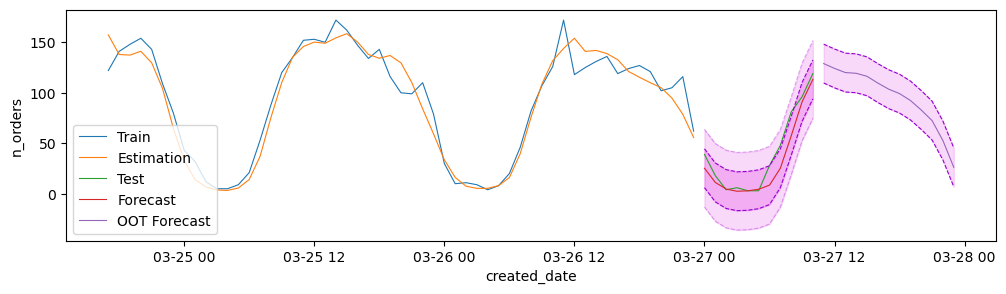

Processing account_id: f9129295-bb08-4330-b60c-9f0beadda521, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 19ms/step - loss: 528770.6875 - val_loss: 511753.0625
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 528765.2500 - val_loss: 511743.6875
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 528750.8750 - val_loss: 511725.0312
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 528727.5000 - val_loss: 511697.8125
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 528695.6875 - val_loss: 511662.1250
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 528655.5625 - val_loss: 511618.9062
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 528607.2500 - val_loss: 511568.1250
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 528551.5625 - val_loss: 511510.0000
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 528489.1250 - val_loss: 511445.1875
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 528416.9375 - val_loss: 511373.5938
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 528344.8750 - val_loss: 511296.3438
Epoch 12/1

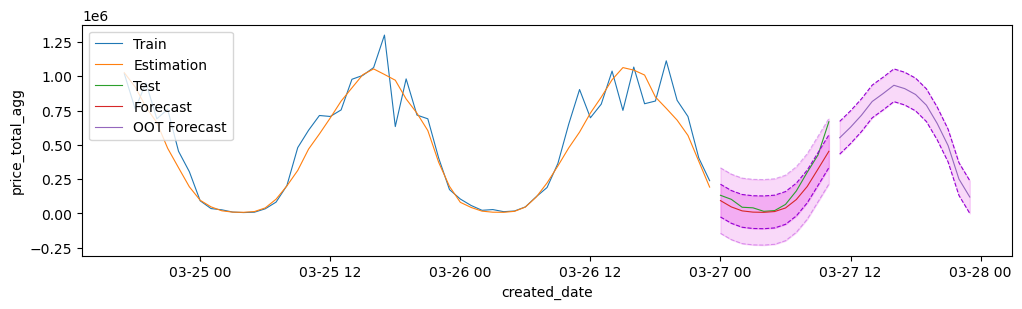

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 32ms/step - loss: 192.7592 - val_loss: 180.0465
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 186.9111 - val_loss: 171.0903
Epoch 3/1000
60/60 - 0s - 5ms/step - loss: 173.4200 - val_loss: 154.7001
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 152.9379 - val_loss: 131.8670
Epoch 5/1000
60/60 - 0s - 5ms/step - loss: 127.2978 - val_loss: 104.9482
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 97.1662 - val_loss: 76.0035
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 68.7174 - val_loss: 46.8842
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 48.1429 - val_loss: 32.1245
Epoch 9/1000
60/60 - 0s - 5ms/step - loss: 43.3785 - val_loss: 30.4163
Epoch 10/1000
60/60 - 0s - 5ms/step - loss: 41.8880 - val_loss: 30.0820
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 43.6190 - val_loss: 29.8626
Epoch 12/1000
60/60 - 0s - 4ms/step - loss: 43.3939 - val_loss: 29.1694
Epoch 13/1000
60/60 - 0s - 4ms/step - loss: 40.5849 - val_loss: 28.9051
Epoch 14/1000
60/60 - 0s - 4ms/ste

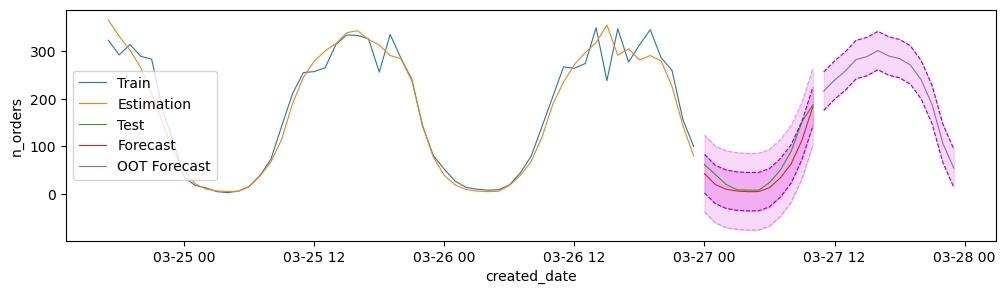

Processing account_id: 22fde42e-45d7-46cd-9d6f-3a4dbabbc579, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 19ms/step - loss: 261.6562 - val_loss: 251.4741
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 261.4902 - val_loss: 251.2483
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 261.1212 - val_loss: 250.6721
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 260.2480 - val_loss: 249.4406
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 258.5428 - val_loss: 247.2534
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 256.0080 - val_loss: 244.0740
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 252.9396 - val_loss: 240.6274
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 249.4549 - val_loss: 236.8081
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 246.4368 - val_loss: 233.4102
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 243.8902 - val_loss: 230.2744
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 241.4001 - val_loss: 227.7979
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 239.5986 - val_loss: 225.6527
Ep

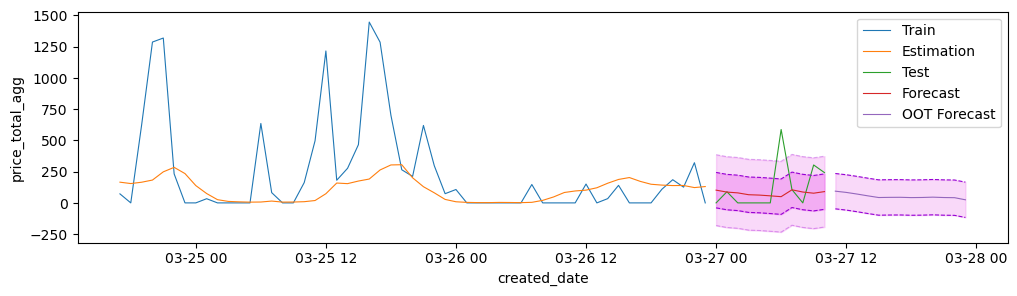

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 15ms/step - loss: 1.6205 - val_loss: 1.2001
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 1.5146 - val_loss: 1.0585
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 1.4126 - val_loss: 0.9637
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.3699 - val_loss: 0.9485
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1.3414 - val_loss: 0.9289
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1.3358 - val_loss: 0.9303
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.3224 - val_loss: 0.9288
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1.3044 - val_loss: 0.9209
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 1.3080 - val_loss: 0.9168
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 1.2941 - val_loss: 0.9185
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 1.2927 - val_loss: 0.9199
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 1.2748 - val_loss: 0.9130
Epoch 13/1000
60/60 - 0s - 3ms/step - loss: 1.2798 - val_loss: 0.9145
Epoch 14/1000
60/60 - 0s - 3ms/step - loss: 1.2662 - val_loss: 0.9118


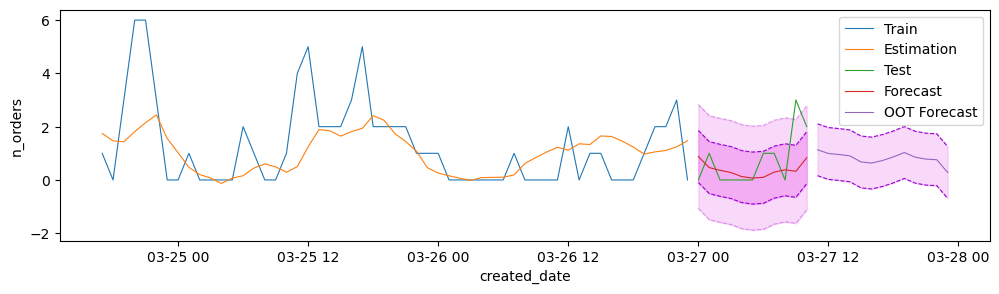

Processing account_id: 0ad2f65b-ee0e-4d50-93e2-84b76282325f, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 33ms/step - loss: 4503.7710 - val_loss: 6033.3848
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 4502.3525 - val_loss: 6029.2627
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 4497.1079 - val_loss: 6017.6860
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 4485.7354 - val_loss: 5997.8291
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 4468.4302 - val_loss: 5970.4893
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 4445.1060 - val_loss: 5935.9473
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 4415.5674 - val_loss: 5894.7959
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 4382.6143 - val_loss: 5848.1245
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 4344.6816 - val_loss: 5796.2812
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 4303.6338 - val_loss: 5740.6626
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 4258.0674 - val_loss: 5680.4038
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 4209.4219 

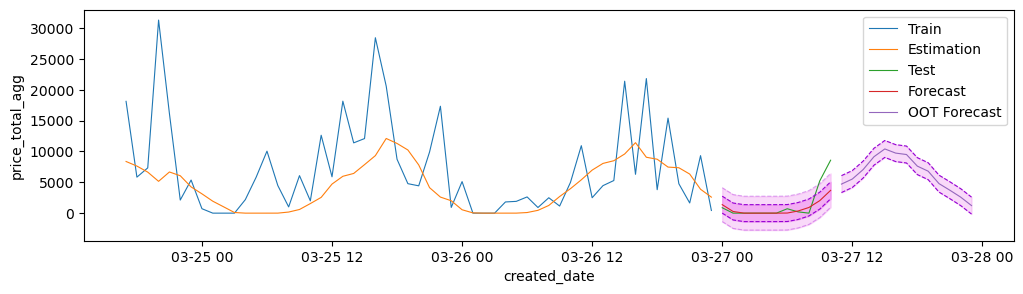

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 20ms/step - loss: 3.7893 - val_loss: 2.8537
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 2.5703 - val_loss: 1.8370
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 2.1088 - val_loss: 1.8472
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 2.0881 - val_loss: 1.8544
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 2.0683 - val_loss: 1.8653
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Epoch 1/1000
61/61 - 1s - 19ms/step - loss: 3.8568 - val_loss: 2.9187
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 2.6873 - val_loss: 1.8177
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 2.1306 - val_loss: 1.8271
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 2.1029 - val_loss: 1.8280
Epoch 5/1000
61/61 - 0s - 3ms/step - loss: 2.0661 - val_loss: 1.8264
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━

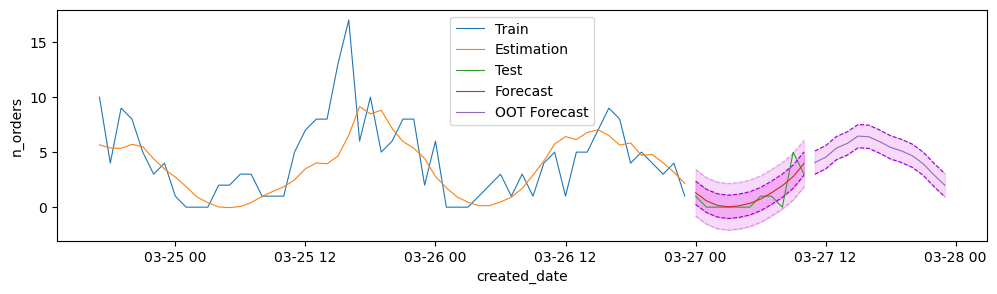

Processing account_id: 5dd8b3ee-6f1c-4ac9-bbc5-91829dde38eb, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 1s - 17ms/step - loss: 5113.5908 - val_loss: 3986.5986
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 5112.3613 - val_loss: 3984.6663
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 5108.9312 - val_loss: 3979.8718
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 5101.8525 - val_loss: 3971.1123
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 5090.3853 - val_loss: 3958.0808
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 5074.9521 - val_loss: 3940.8096
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 5054.8589 - val_loss: 3919.2119
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 5030.2368 - val_loss: 3893.5374
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 5002.5303 - val_loss: 3864.1311
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 4969.7080 - val_loss: 3830.6521
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 4935.0381 - val_loss: 3793.6064
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 4894.6572 

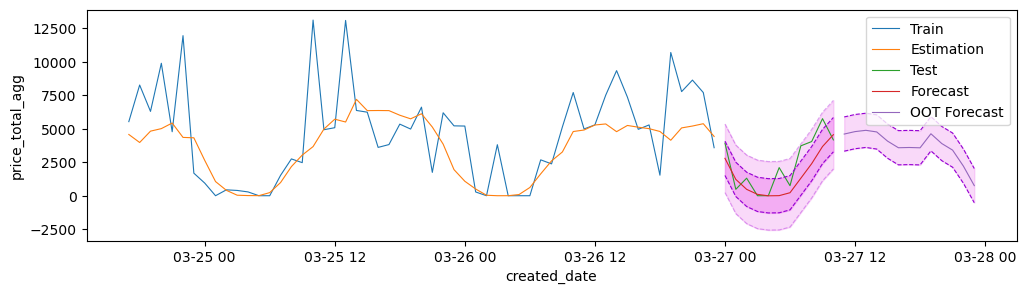

Processing column: n_orders
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 12.0950 - val_loss: 7.7222
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 11.0474 - val_loss: 6.0882
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 8.9108 - val_loss: 4.0424
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 6.2867 - val_loss: 3.3020
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 5.3090 - val_loss: 3.0958
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 5.2314 - val_loss: 3.0625
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 5.0839 - val_loss: 3.0491
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 5.0048 - val_loss: 3.0315
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 4.8381 - val_loss: 3.0100
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 4.9025 - val_loss: 2.9859
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 4.7424 - val_loss: 2.9942
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 4.7300 - val_loss: 2.9996
Epoch 13/1000
60/60 - 0s - 2ms/step - loss: 4.7729 - val_loss: 3.0098
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1

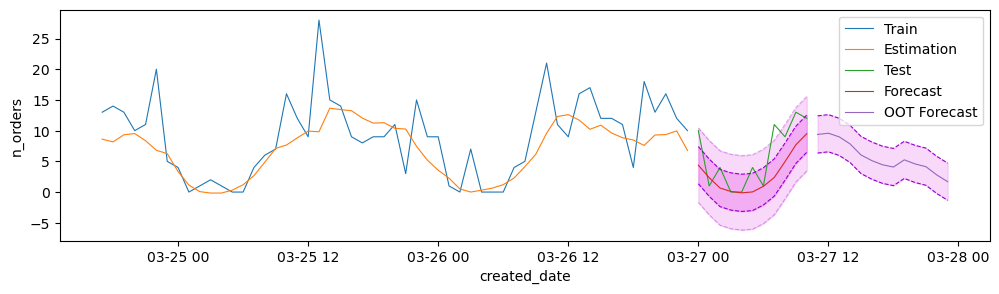

Processing account_id: aabe992c-cfad-4049-b5df-36c41f900a67, sales_channel_id: ALL
Processing column: price_total_agg
Epoch 1/1000
60/60 - 2s - 34ms/step - loss: 82.2469 - val_loss: 130.6317
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 82.2283 - val_loss: 130.6291
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 82.2159 - val_loss: 130.6214
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 82.2021 - val_loss: 130.6114
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 82.1834 - val_loss: 130.5952
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 82.1494 - val_loss: 130.5751
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 82.1149 - val_loss: 130.5445
Epoch 8/1000
60/60 - 0s - 5ms/step - loss: 82.0727 - val_loss: 130.5045
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 82.0090 - val_loss: 130.4507
Epoch 10/1000
60/60 - 0s - 5ms/step - loss: 81.9481 - val_loss: 130.3929
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 81.8628 - val_loss: 130.3249
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 81.7529 - val_loss: 130.2376
Epoch 13/1000


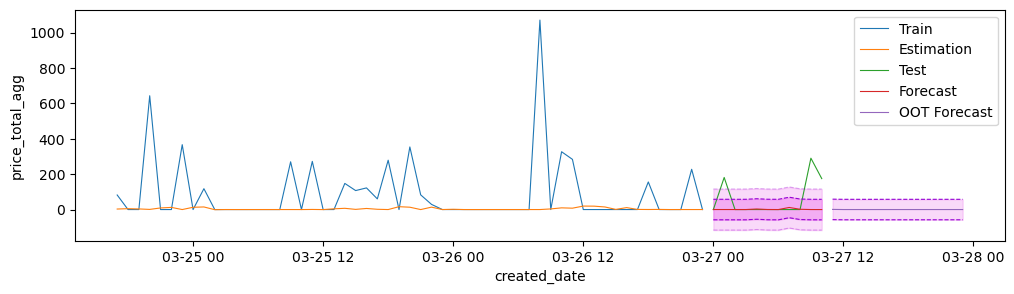

Processing column: n_orders
Epoch 1/1000
60/60 - 2s - 25ms/step - loss: 0.4167 - val_loss: 0.4828
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 0.4034 - val_loss: 0.4814
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.3970 - val_loss: 0.4801
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.3943 - val_loss: 0.4794
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 0.3901 - val_loss: 0.4790
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 0.3877 - val_loss: 0.4762
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 0.3851 - val_loss: 0.4753
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 0.3858 - val_loss: 0.4753
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 0.3823 - val_loss: 0.4743
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 0.3802 - val_loss: 0.4750
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 0.3799 - val_loss: 0.4762
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 0.3796 - val_loss: 0.4772
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Epoch 1/1000
61/61 - 1s - 22ms/step - loss: 0.4184 - val_loss: 

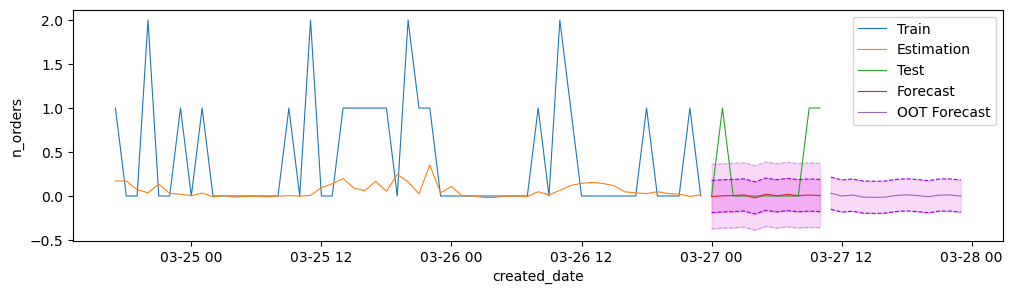

In [9]:
def preprocess_sales_data(account_id, sales_channel_id):
    if sales_channel_id == 'ALL':
        cond = (sales['account_id'] == account_id) & \
               (sales['status'].notna())
    else:
        cond = (sales['account_id'] == account_id) & \
               (sales['sales_channel_id'] == sales_channel_id) & \
               (sales['status'].notna())
    df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
    df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
    df_client = df_client.sort_values('created_date').reset_index(drop=True)
    df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)

    df_client_mod = df_client.groupby('created_date').agg(
        price_total_agg=('price_total', 'sum'),
        n_orders=('created_date', 'count')
    )
    df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')

    end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
    start_date = end_date - relativedelta(months=LOOKBACK)
    date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
    df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

    oot_date_index = pd.Series(df_oot.index, name='created_date')
    combined_date_index = pd.concat([date_index, oot_date_index], axis=0)
    df_client_mod = pd.merge(combined_date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

    return df_client_mod


def create_lagged_features(df, lags=24):
    lagged_features = [df.shift(l).rename(f'lag_{l}') for l in range(1, lags + 1)]
    df_lag = pd.concat([df, pd.concat(lagged_features, axis=1)], axis=1).dropna().asfreq('h')
    return df_lag


def split_data(df_lag):
    df_train = df_lag.loc[df_lag.index < START_DATE].copy()
    df_test = df_lag.loc[(df_lag.index >= START_DATE) & (df_lag.index <= END_DATE)].copy()
    df_oot = df_lag.loc[df_lag.index > END_DATE].copy()
    return df_train, df_test, df_oot


def train_and_forecast(df_train, df_test, df_full, df_oot, col):
    X_train, y_train = df_train.drop(col, axis=1), df_train[col]
    X_test = df_test.drop(col, axis=1)
    X_full, y_full = df_full.drop(col, axis=1), df_full[col]
    X_oot = df_oot.drop(col, axis=1)
    
    train_mad = y_train.std()
    mad = y_full.std()
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    X_train_scaled = np.reshape(X_train_scaled, (X_train.shape[0], 1, X_train.shape[1]))
    X_test_scaled = np.reshape(X_test_scaled, (X_test.shape[0], 1, X_test.shape[1]))
    
    early_stopping = EarlyStopping(patience=3)
    model = Sequential()
    model.add(Input(shape=(1, 24)))
    model.add(LSTM(128, activation='relu', return_sequences=True))
    model.add(Dropout(0.5))
    model.add(Dense(1))
    model.compile(loss='mean_absolute_error', optimizer='adam')
    model.fit(X_train_scaled, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALID_SPLIT, shuffle=False, callbacks=early_stopping, verbose=2)
    
    estimations = pd.Series(model.predict(X_train_scaled).squeeze(), index=X_train.index)

    forecast = pd.Series(model.predict(X_test_scaled).squeeze(), index=X_test.index)
    forecast_lower = forecast - CRIT_VALUE*train_mad
    forecast_upper = forecast + CRIT_VALUE*train_mad
    
    scaler = StandardScaler()
    X_full_scaled = np.reshape(scaler.fit_transform(X_full), (X_full.shape[0], 1, X_full.shape[1]))

    early_stopping = EarlyStopping(patience=3)
    oot_model = Sequential()
    oot_model.add(Input(shape=(1, 24)))
    oot_model.add(LSTM(128, activation='relu', return_sequences=True))
    oot_model.add(Dropout(0.5))
    oot_model.add(Dense(1))
    oot_model.compile(loss='mean_absolute_error', optimizer='adam')
    oot_model.fit(X_full_scaled, y_full, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALID_SPLIT, shuffle=False, callbacks=early_stopping, verbose=2)
    
    oot_forecast_ls = []
    oot_forecast_lower_ls = []
    oot_forecast_upper_ls = []
    for i in range(len(X_oot)):
        x_oot = X_oot.iloc[i].to_frame().T
        x_oot_scaled = scaler.transform(x_oot)
        x_oot_scaled = np.reshape(x_oot_scaled, (x_oot.shape[0], 1, x_oot.shape[1]))
        
        x_oot_forecast = oot_model.predict(x_oot_scaled).squeeze()
        oot_forecast_ls.append(x_oot_forecast)
        oot_forecast_lower_ls.append(x_oot_forecast - CRIT_VALUE*mad)
        oot_forecast_upper_ls.append(x_oot_forecast + CRIT_VALUE*mad)
        
        for j, k in list(zip(range(i+1, len(X_oot)), range(len(X_oot)-i-1))):
            X_oot.iloc[j, k] = x_oot_forecast
            
    oot_forecast = pd.Series(oot_forecast_ls, index=X_oot.index).astype(float)
    oot_forecast_lower = pd.Series(oot_forecast_lower_ls, index=X_oot.index)
    oot_forecast_upper = pd.Series(oot_forecast_upper_ls, index=X_oot.index)

    return {
        'estimations': estimations,
        'forecast': forecast,
        'forecast_lower': forecast_lower,
        'forecast_upper': forecast_upper,
        'oot_forecast': oot_forecast,
        'oot_forecast_lower': oot_forecast_lower,
        'oot_forecast_upper': oot_forecast_upper
    }
    
    
def compute_metrics_and_plot_time_series(forecast_results, df_train, df_test, col):
    y_train = df_train[col]
    y_test = df_test[col]
    estimations = forecast_results['estimations']
    forecast = forecast_results['forecast']
    forecast_lower = forecast_results['forecast_lower']
    forecast_upper = forecast_results['forecast_upper']
    oot_forecast = forecast_results['oot_forecast']
    oot_forecast_lower = forecast_results['oot_forecast_lower']
    oot_forecast_upper = forecast_results['oot_forecast_upper']
    
    train_mae = mean_absolute_error(df_train[col], estimations)
    train_rmse = root_mean_squared_error(df_train[col], estimations)
    print(f"train RMSE: {train_rmse:.3f}")
    print(f"train MAE:  {train_mae:.3f}")
    test_mae = mean_absolute_error(df_test[col], forecast)
    test_rmse = root_mean_squared_error(df_test[col], forecast)
    print(f"test RMSE: {test_rmse:.3f}")
    print(f"test MAE:  {test_mae:.3f}")
    
    plt.figure(figsize=(12, 3))
    sns.lineplot(y_train.iloc[-5*TEST_SIZE:], lw=0.8, label='Train')
    sns.lineplot(estimations.iloc[-5*TEST_SIZE:], lw=0.8, label='Estimation')
    sns.lineplot(y_test, lw=0.8, label='Test')
    sns.lineplot(forecast, lw=0.8, label='Forecast')
    sns.lineplot(forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(2*forecast_lower-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
    sns.lineplot(2*forecast_upper-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
    sns.lineplot(oot_forecast, lw=0.8, label='OOT Forecast')
    sns.lineplot(oot_forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(oot_forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
    plt.fill_between(x=forecast.index,
                     y1=forecast_lower,
                     y2=forecast_upper,
                     color='violet',
                     alpha=0.5)
    plt.fill_between(x=forecast.index,
                     y1=2*forecast_lower-forecast,
                     y2=2*forecast_upper-forecast,
                     color='violet',
                     alpha=0.3)
    plt.fill_between(x=oot_forecast.index,
                     y1=oot_forecast_lower,
                     y2=oot_forecast_upper,
                     color='violet',
                     alpha=0.3)
    plt.legend()
    plt.savefig(f'plots/machine_learning/forecast_{account_id}_{sales_channel_id}_{col}_dl.png')
    plt.show()
    
    return train_rmse, test_rmse, train_mae, test_mae


def save_forecast_to_sql(account_id, sales_channel_id, df_test, df_oot, forecast_dict):
    with open(f'sql/time_series/forecast_{account_id}_{sales_channel_id}_ts.sql', 'w') as output_file:
        for i in range(len(df_test)):
            start_time = df_test.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                      channel, seller, account_id, organization_id, store_id, minutes_interval,
                                      model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'TBATS',
                        {forecast_dict['dataset_1']['forecast_upper'].iloc[i]}, {forecast_dict['dataset_1']['forecast_lower'].iloc[i]}, {forecast_dict['dataset_1']['forecast'].iloc[i]},
                        {forecast_dict['dataset_0']['forecast_upper'].iloc[i]}, {forecast_dict['dataset_0']['forecast_lower'].iloc[i]}, {forecast_dict['dataset_0']['forecast'].iloc[i]});
                """
            )
        for i in range(len(df_oot)):
            start_time = df_oot.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                      channel, seller, account_id, organization_id, store_id, minutes_interval,
                                      model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'TBATS',
                        {forecast_dict['dataset_1']['oot_forecast_upper'].iloc[i]}, {forecast_dict['dataset_1']['oot_forecast_lower'].iloc[i]}, {forecast_dict['dataset_1']['oot_forecast'].iloc[i]},
                        {forecast_dict['dataset_0']['oot_forecast_upper'].iloc[i]}, {forecast_dict['dataset_0']['oot_forecast_lower'].iloc[i]}, {forecast_dict['dataset_0']['oot_forecast'].iloc[i]});
                """
            )


# Main
if ALL_SALES_CHANNELS:
    id_pairs = set(list(zip(df_count['account_id'], ['ALL']*len(df_count))))
else:
    id_pairs = list(zip(df_count['account_id'], df_count['sales_channel_id']))

summary_dict = {}
for account_id, sales_channel_id in id_pairs:
    print(f'Processing account_id: {account_id}, sales_channel_id: {sales_channel_id}')
    summary_dict[(account_id, sales_channel_id)] = {}

    df_client_mod = preprocess_sales_data(account_id, sales_channel_id)
    df_client_mod.fillna(0, inplace=True)

    forecast_dict = {}
    for n, col in enumerate(['price_total_agg', 'n_orders']):
        print(f'Processing column: {col}')
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}'] = {'name': col}

        df_lag = create_lagged_features(df_client_mod[col])
        df_train, df_test, df_oot = split_data(df_lag)
        df_full = pd.concat([df_train, df_test], axis=0)

        forecast_results = train_and_forecast(df_train, df_test, df_full, df_oot, col)
        
        forecast_dict[f'dataset_{n}'] = {}
        forecast_dict[f'dataset_{n}'].update(forecast_results)
        
        train_rmse, test_rmse, train_mae, test_mae = compute_metrics_and_plot_time_series(forecast_results, df_train, df_test, col)
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train RMSE'] = train_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test RMSE'] = test_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train MAE'] = train_mae
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test MAE'] = test_mae

    save_forecast_to_sql(account_id, sales_channel_id, df_test, df_oot, forecast_dict)

In [10]:
dataset_0 = pd.DataFrame({k: v['dataset_0'] for k, v in summary_dict.items()}).T
dataset_1 = pd.DataFrame({k: v['dataset_1'] for k, v in summary_dict.items()}).T

In [11]:
summary = (
    pd
    .concat([dataset_0, dataset_1], axis=0)
    .rename({'name': 'dataset'}, axis=1)
    .sort_index()
    .reset_index(names=['account_id', 'sales_channel_id'])
)
summary.to_csv('summary_ml.csv', sep=';')

summary

,account_id,sales_channel_id,dataset,train RMSE,test RMSE,train MAE,test MAE
0,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,ALL,price_total_agg,14986.330067,3398.863282,8594.223887,2451.40877
1,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,ALL,n_orders,38.687976,12.651062,18.76549,9.346282
2,0661e926-f219-456e-bde5-612fee6f891c,ALL,price_total_agg,938.865686,389.355416,363.782356,270.407031
3,0661e926-f219-456e-bde5-612fee6f891c,ALL,n_orders,4.887673,1.215497,1.554114,0.945065
4,0ad2f65b-ee0e-4d50-93e2-84b76282325f,ALL,price_total_agg,4655.140644,1802.932348,2822.322391,964.597
...,...,...,...,...,...,...,...
69,e2de40dd-743b-4105-9077-3f343fea980d,ALL,n_orders,5.187828,2.588131,3.347552,2.008538
70,f4471620-212b-4991-98d3-b498835d0c29,ALL,price_total_agg,0.0,0.0,0.0,0.0
71,f4471620-212b-4991-98d3-b498835d0c29,ALL,n_orders,0.0,0.0,0.0,0.0
72,f9129295-bb08-4330-b60c-9f0beadda521,ALL,price_total_agg,158994.468342,84599.300752,100444.705311,61518.464609


In [12]:
train_metrics = summary.groupby('dataset')['train MAE'].mean()

train_metrics

dataset
n_orders              3.457275
price_total_agg    3812.650291
Name: train MAE, dtype: object

In [13]:
test_metrics = summary.groupby('dataset')['test MAE'].mean()

test_metrics

dataset
n_orders              1.771837
price_total_agg    2330.574252
Name: test MAE, dtype: object

In [14]:
(train_metrics - test_metrics).abs()

dataset
n_orders              1.685437
price_total_agg    1482.076039
dtype: object